# PREDICTIVE ANALYSIS

Predictive Analytics: The Zen of Five Heart Failure Patient Dataset
What is predictive analysis? It answers "what is likely to happen?" by building statistical/ML models on historical data to forecast future outcomes for new or existing patients — mortality risk, readmission likelihood, length of stay, lab trajectories, and more.

Each question follows

Reasoning  why this prediction matters and how it would be used clinically/operationally
Analysis the model(s) built to answer it (classification, regression, or multi-class), with proper train/test splitting, evaluation metrics, and visualizations
Insight what the model tells us and how confident we should be in it


## Setup & Data Load

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, accuracy_score, precision_recall_curve,
                              mean_absolute_error, r2_score, confusion_matrix, ConfusionMatrixDisplay,
                              brier_score_loss)
from sklearn.calibration import calibration_curve

pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
RANDOM_STATE = 42


In [8]:
from scipy.stats import chi2_contingency, mannwhitneyu, kruskal

In [9]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

print(X2_train.shape, X2_test.shape)

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency, mannwhitneyu, kruskal
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_curve, roc_auc_score,
                              classification_report)

In [18]:
# Robust CSV loader
FILENAME = 'cardiac_failure/Team4_The_Zen_Of_Five_cleaned_data.csv'
candidate_paths = [
    FILENAME,
    os.path.join(os.getcwd(), FILENAME),
    os.path.join(os.path.expanduser('~'), 'Downloads', FILENAME),
    os.path.join(os.path.expanduser('~'), 'Desktop', FILENAME),
]

df = None
for p in candidate_paths:
    if os.path.exists(p):
        df = pd.read_csv(p)
        print(f"Loaded data from: {p}")
        break

if df is None:
    raise FileNotFoundError(
        f"Could not find '{FILENAME}'. Looked in:\n  " + "\n  ".join(candidate_paths) +
        f"\n\nCurrent working directory is: {os.getcwd()}\n"
        "Fix: move the CSV into this folder, or edit candidate_paths above."
    )

print("Shape:", df.shape)
df.head(3)


Loaded data from: cardiac_failure/Team4_The_Zen_Of_Five_cleaned_data.csv
Shape: (2008, 200)


,inpatient_number,gender,weight,height,bmi,occupation,agecat,flag_invalid_height,flag_invalid_weight,bmi_category,total_prescriptions_count,rx_aspirin_enteric-coated_tablet,rx_atorvastatin_calcium_tablet,rx_benazepril_hydrochloride_tablet,rx_clopidogrel_hydrogen_sulphate_tablet,rx_deslanoside_injection,rx_digoxin_tablet,rx_dobutamine_hydrochloride_injection,rx_enoxaparin_sodium_injection,rx_furosemide_injection,rx_furosemide_tablet,rx_heparin_sodium_injection,rx_hydrochlorothiazide_tablet,rx_isoprenaline_hydrochloride_injection,rx_isosorbide_mononitrate_sustained_release_tablet,rx_meglumine_adenosine_cyclophosphate_for_injection,rx_metoprolol_succinate_sustained-release_tablet,rx_milrinone_injection,rx_nitroglycerin_injection,rx_shenfu_injection,...,sodium_ion,glucose_blood_gas,lactate,measured_residual_base,measured_bicarbonate,carboxyhemoglobin,body_temperature_blood_gas,oxygen_saturation,partial_oxygen_pressure,oxyhemoglobin,anion_gap,free_calcium,total_hemoglobin,shock_index,bun_creatinine_ratio,anion_gap_calc,pf_ratio,nyha_cardiac_function_classification,killip_grade,myocardial_infarction,congestive_heart_failure,peripheral_vascular_disease,type_of_heart_failure,lvef,left_ventricular_end_diastolic_diameter_lv,mitral_valve_ems,mitral_valve_ams,ea,tricuspid_valve_return_velocity,tricuspid_valve_return_pressure
0,827040,Female,50.0,1.45,23.781213,Unspecified,69-79,False,False,Normal,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.508333,0.121038,NaN,NaN,3,2,0,1,0,Both,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,857781,Male,50.0,1.64,18.590125,Urban Resident,69-79,False,False,Normal,13.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,...,136.4,5.8,2.5,NaN,21.2,0.4,37.0,97.0,93.0,95.9,17.8,1.14,125.0,0.852941,0.115882,11.5,2.818182,3,3,0,0,0,Both,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,743087,Female,51.0,1.63,19.195303,Urban Resident,69-79,False,False,Normal,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.633333,0.069194,NaN,NaN,3,1,0,0,0,Both,NaN,40.0,1.16,1.52,NaN,3.34,47.0


# 1: Can we predict, using only information available at admission, whether a heart failure patient will be readmitted within 6 months so hospitals can act preventively rather than reactively?

**Hypotheses**

**H₀ (null):** Admission-time clinical features (vitals, labs, comorbidity burden, HF type, demographics) have no predictive relationship with 6-month readmission is effectively random with respect to these variables.

**H₁ (alternate):** Admission-time clinical features do carry predictive signal for 6-month readmission a model trained on them will perform meaningfully better than random guessing (AUC > 0.5).

**Reasoning:**
Doctors want to know, right when a heart failure patient walks in, whether that patient is likely to come back to the hospital within the next 6 months so they can step in early (extra follow-up, medication checks) instead of just waiting and reacting after it happens. We can only use information available at the moment of admission, since anything that happens after discharge wouldn't help the hospital plan ahead. Testing this with a prediction model tells us honestly how much the admission data alone can (or can't) forecast which is genuinely useful either way.

**Parameters and Their Clinical Connection to Readmission Risk**

| Parameter | Type | Connection to 6-month readmission risk |
|---|---|---|
| `cci_score` | Numeric | More chronic conditions on board means more competing health problems that can independently trigger a return trip to the hospital, not just the heart itself. |
| `systolic_blood_pressure` | Numeric | Abnormally low BP at admission can signal poor cardiac output; a key marker of hemodynamic instability. |
| `diastolic_blood_pressure` | Numeric | High or low diastolic pressure reflects vascular tone/uncontrolled hypertension, a common driver of HF decompensation. |
| `pulse` | Numeric | An elevated resting heart rate suggests the heart is compensating for reduced pumping efficiency — a sign of instability. |
| `brain_natriuretic_peptide` | Numeric | Directly measures cardiac wall stress from fluid overload — the single most HF-specific lab in the dataset, and a well-established readmission predictor. |
| `creatinine_enzymatic_method` | Numeric | Poor kidney function limits how aggressively diuretics can be used, tied to cardiorenal syndrome risk — a known driver of bounce-back admissions. |
| `sodium` | Numeric | Low sodium (hyponatremia) reflects how far the body has fallen into fluid-retention compensation — already linked to worse outcomes in this analysis. |
| `potassium` | Numeric | Electrolyte imbalance risk, especially relevant with diuretic/MRA use — abnormal levels can precipitate an event requiring readmission. |
| `hemoglobin` | Numeric | Anemia increases cardiac workload (the heart pumps harder to deliver oxygen), independently worsening HF prognosis. |
| `white_blood_cell` | Numeric | Can flag an underlying infection triggering the HF episode — a root cause that, if missed, could resurface after discharge. |
| `platelet` | Numeric | General marker of physiological stress; included as a broad stability indicator. |
| `lvef` | Numeric | Defines HF type and severity (HFrEF vs. HFpEF) — directly tied to which medications are indicated and how fragile pumping function is. |
| `total_prescriptions_count` | Numeric | Proxy for medication complexity/polypharmacy — more medications can mean better guideline coverage, but also more risk of confusion managing them at home. |
| `gender` | Categorical | Demographic context capturing baseline risk differences not reflected in labs alone. |
| `bmi_category` | Categorical | Body-composition context; both very low and very high BMI carry distinct HF risk profiles. |
| `admission_way` | Categorical | How urgently the patient arrived (Emergency vs. Non-Emergency) reflects how destabilized they already were before hospitalization. |
| `type_of_heart_failure` | Categorical | Biventricular (both-sided) failure — the most common and most advanced form in this cohort — may carry distinct readmission risk from isolated left- or right-sided failure. |
| `nyha_cardiac_function_classification` | Categorical | Captures how limited the patient's daily life already was *before* this admission — a direct measure of chronic disease severity. |

**Target Variable**

| Parameter | Value |
|---|---|
| Target column | `re_admission_within_6_months` |
| Type | Binary classification |
| 0 = | Not readmitted within 6 months |
| 1 = | Readmitted within 6 months |
| Why this target | Predicting this at admission lets hospitals act preventively (early follow-up, case management) instead of reacting after the patient bounces back. |

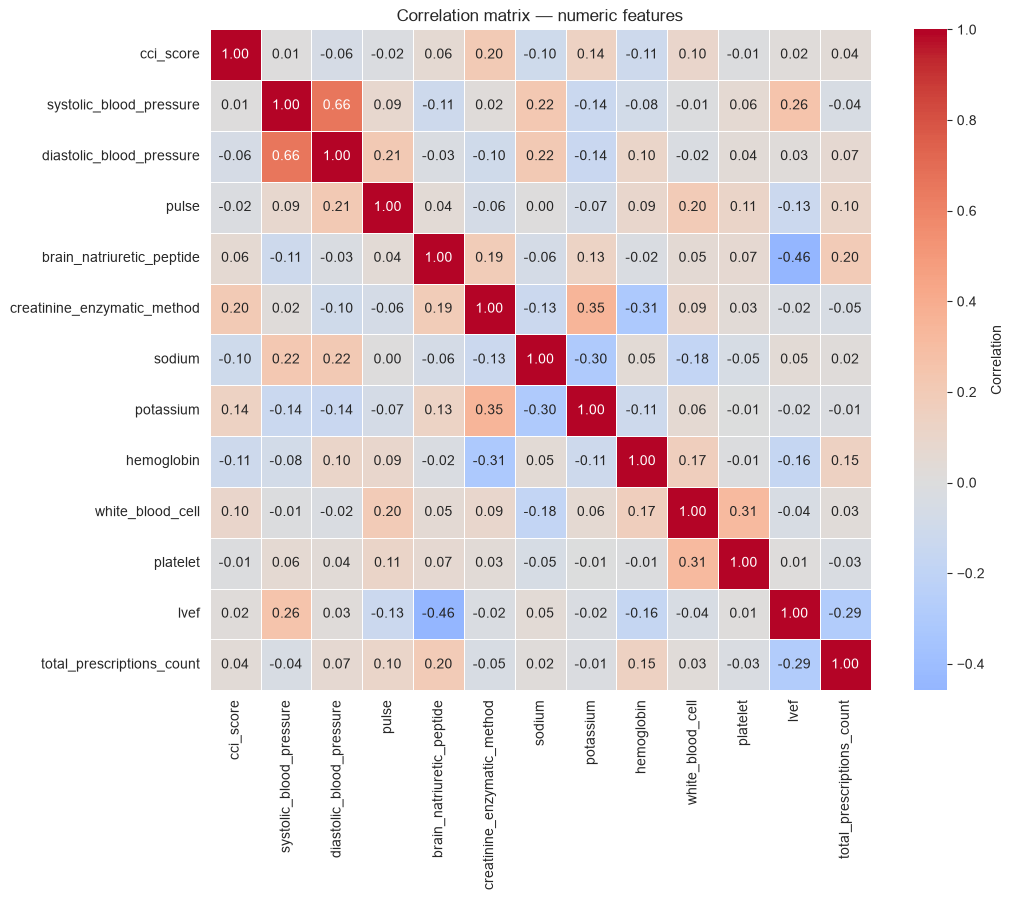

In [19]:
# ============================================================
# CORRELATION CHECK
# ============================================================

# --- 1. Correlation matrix among numeric features (check for multicollinearity) ---

numeric_cols = ['cci_score', 'systolic_blood_pressure', 'diastolic_blood_pressure', 'pulse',
                 'brain_natriuretic_peptide', 'creatinine_enzymatic_method', 'sodium', 'potassium',
                 'hemoglobin', 'white_blood_cell', 'platelet', 'lvef', 'total_prescriptions_count']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Correlation matrix — numeric features')
plt.tight_layout(); plt.show()

Top 10 most correlated feature pairs:
systolic_blood_pressure      diastolic_blood_pressure       0.663456
diastolic_blood_pressure     systolic_blood_pressure        0.663456
brain_natriuretic_peptide    lvef                           0.458612
lvef                         brain_natriuretic_peptide      0.458612
potassium                    creatinine_enzymatic_method    0.350118
creatinine_enzymatic_method  potassium                      0.350118
white_blood_cell             platelet                       0.314519
platelet                     white_blood_cell               0.314519
hemoglobin                   creatinine_enzymatic_method    0.312395
creatinine_enzymatic_method  hemoglobin                     0.312395
dtype: float64

Pairs with |correlation| > 0.6 (potential multicollinearity to watch for):
systolic_blood_pressure   diastolic_blood_pressure    0.663456
diastolic_blood_pressure  systolic_blood_pressure     0.663456
dtype: float64
Correlation of each feature with 6-month

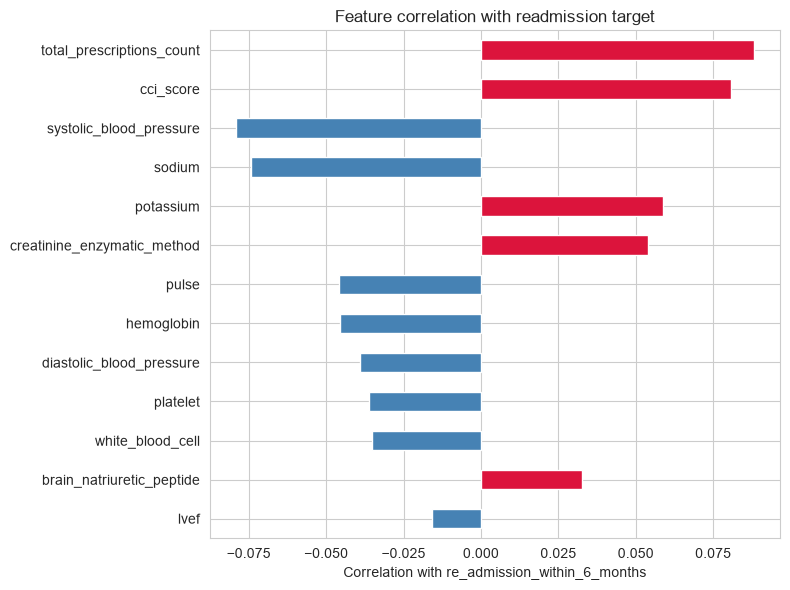

In [20]:
# --- 2. Flag any highly correlated feature pairs (potential redundancy) ---

corr_pairs = corr_matrix.abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0]  # remove self-correlation (always 1.0)
corr_pairs = corr_pairs[~corr_pairs.index.duplicated()]  # remove mirrored duplicates

print("Top 10 most correlated feature pairs:")
print(corr_pairs.head(10))
print()
print("Pairs with |correlation| > 0.6 (potential multicollinearity to watch for):")
print(corr_pairs[corr_pairs > 0.6])

# --- 3. Correlation of each numeric feature with the TARGET variable ---

target_corr = df[numeric_cols + ['re_admission_within_6_months']].corr()['re_admission_within_6_months'].drop('re_admission_within_6_months')
target_corr = target_corr.sort_values(key=abs, ascending=False)

print("Correlation of each feature with 6-month readmission:")
print(target_corr)

plt.figure(figsize=(8, 6))
target_corr.plot(kind='barh', color=['crimson' if v > 0 else 'steelblue' for v in target_corr])
plt.xlabel('Correlation with re_admission_within_6_months')
plt.title('Feature correlation with readmission target')
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

**Correlation matrix:** watch for any two features with correlation above ~0.7-0.8 that's a sign of redundancy (multicollinearity), which can make a Logistic Regression's coefficients unstable (though tree-based models like Random Forest/Gradient Boosting handle it fine).

**Target correlation:** individual correlations with a binary outcome are usually fairly weak (often under 0.15-0.2 in real clinical data) that's normal and expected, and it's consistent with your earlier finding that no single lab alone strongly predicts readmission, which is why you needed a combined model/score instead of one variable.

**Checking categorical values:**

In [21]:

cat_cols = ['gender', 'bmi_category', 'admission_way', 'type_of_heart_failure',
            'nyha_cardiac_function_classification']

for col in cat_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()

--- gender ---
gender
Female    1163
Male       845
Name: count, dtype: int64

--- bmi_category ---
bmi_category
Normal         1163
Underweight     507
Overweight      263
Obese            67
NaN               8
Name: count, dtype: int64

--- admission_way ---
admission_way
NonEmergency    1052
Emergency        956
Name: count, dtype: int64

--- type_of_heart_failure ---
type_of_heart_failure
Both     1480
Left      477
Right      51
Name: count, dtype: int64

--- nyha_cardiac_function_classification ---
nyha_cardiac_function_classification
3    1039
4     616
2     353
Name: count, dtype: int64



In [22]:
for col in cat_cols:
    print(f"--- Readmission rate by {col} ---")
    print(df.groupby(col)['re_admission_within_6_months'].mean().sort_values(ascending=False))
    print()

--- Readmission rate by gender ---
gender
Male      0.396450
Female    0.376612
Name: re_admission_within_6_months, dtype: float64

--- Readmission rate by bmi_category ---
bmi_category
Underweight    0.410256
Overweight     0.395437
Obese          0.388060
Normal         0.373173
Name: re_admission_within_6_months, dtype: float64

--- Readmission rate by admission_way ---
admission_way
NonEmergency    0.385932
Emergency       0.383891
Name: re_admission_within_6_months, dtype: float64

--- Readmission rate by type_of_heart_failure ---
type_of_heart_failure
Both     0.422297
Right    0.352941
Left     0.272537
Name: re_admission_within_6_months, dtype: float64

--- Readmission rate by nyha_cardiac_function_classification ---
nyha_cardiac_function_classification
4    0.446429
3    0.380173
2    0.291785
Name: re_admission_within_6_months, dtype: float64



**Model Building:**

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

target = 're_admission_within_6_months'
numeric_cols = ['cci_score', 'systolic_blood_pressure', 'diastolic_blood_pressure', 'pulse',
                 'brain_natriuretic_peptide', 'creatinine_enzymatic_method', 'sodium', 'potassium',
                 'hemoglobin', 'white_blood_cell', 'platelet', 'lvef', 'total_prescriptions_count']
cat_cols = ['gender', 'bmi_category', 'admission_way', 'type_of_heart_failure',
            'nyha_cardiac_function_classification']

use_cols = numeric_cols + cat_cols
X = df[use_cols].copy()
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

preprocess = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), numeric_cols),
    ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))]), cat_cols)
])

models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'DecisionTree': DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=400, class_weight='balanced', random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42)
}

results = {}
for name, model in models.items():
    pipe = Pipeline([('prep', preprocess), ('clf', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    results[name] = {
        'accuracy': accuracy_score(y_test, preds),
        'precision': precision_score(y_test, preds),
        'recall': recall_score(y_test, preds),
        'f1': f1_score(y_test, preds),
        'auc': roc_auc_score(y_test, proba)
    }

results_df = pd.DataFrame(results).T.round(3)
print(results_df)

                    accuracy  precision  recall     f1    auc
LogisticRegression     0.584      0.469   0.617  0.532  0.624
DecisionTree           0.602      0.482   0.487  0.485  0.585
RandomForest           0.639      0.538   0.446  0.487  0.636
GradientBoosting       0.618      0.504   0.337  0.404  0.642


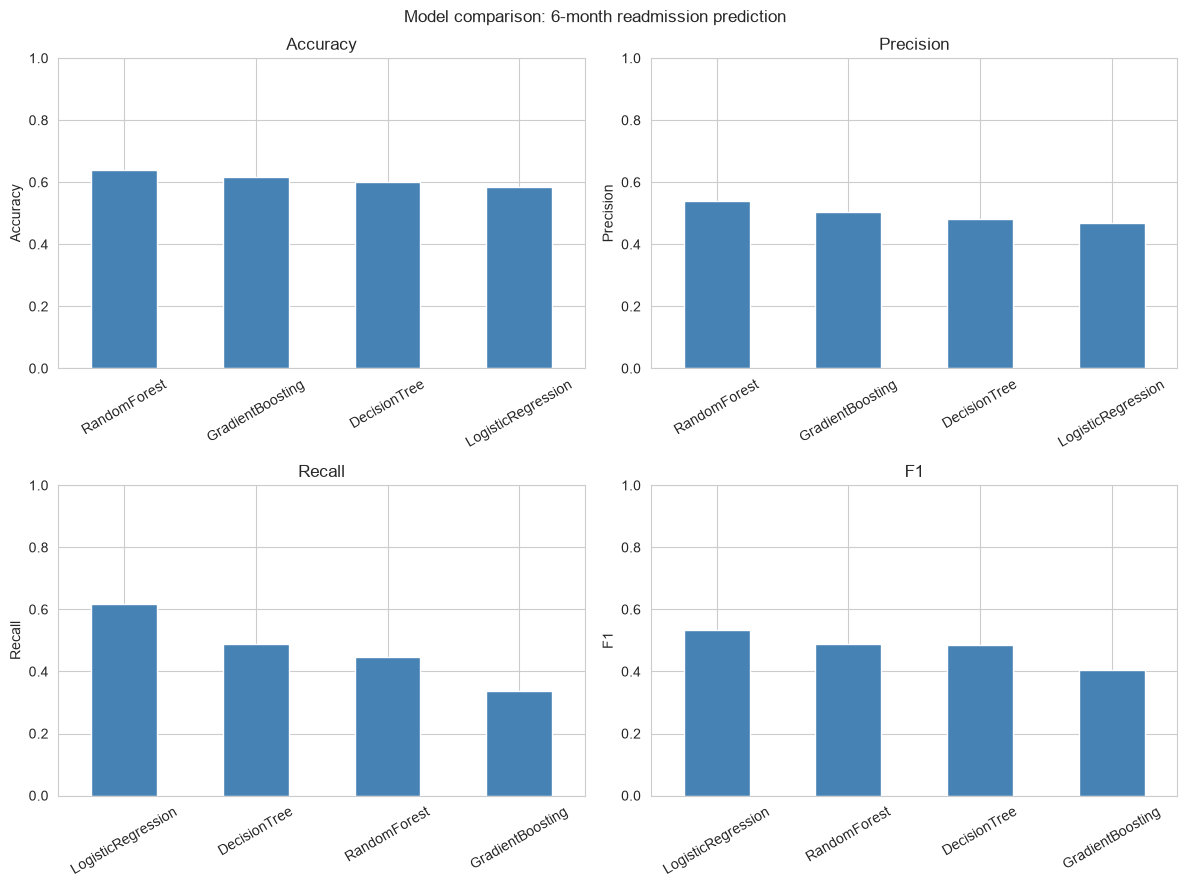

In [24]:
metrics = ['accuracy', 'precision', 'recall', 'f1']
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, metric in zip(axes.ravel(), metrics):
    results_df[metric].sort_values(ascending=False).plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(metric.capitalize())
    ax.set_ylabel(metric.capitalize())
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Model comparison: 6-month readmission prediction')
plt.tight_layout()
plt.show()

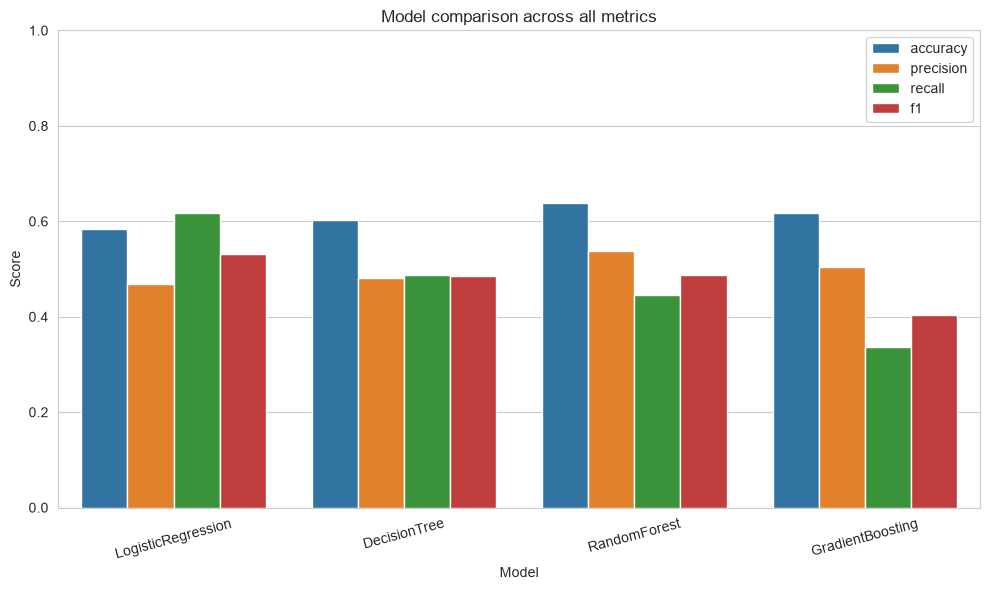

In [25]:
plot_df = results_df[['accuracy','precision','recall','f1']].reset_index().melt(id_vars='index', var_name='Metric', value_name='Score')
plot_df = plot_df.rename(columns={'index':'Model'})

plt.figure(figsize=(10,6))
sns.barplot(data=plot_df, x='Model', y='Score', hue='Metric')
plt.ylim(0, 1)
plt.title('Model comparison across all metrics')
plt.xticks(rotation=15)
plt.legend(title='', loc='upper right')
plt.tight_layout(); plt.show()

**Choosing one final model**

In [26]:
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay

# Rebuild the chosen pipeline (Logistic Regression -- best recall/F1)
final_model_name = 'LogisticRegression'
final_pipe = Pipeline([('prep', preprocess), ('clf', models[final_model_name])])
final_pipe.fit(X_train, y_train)

final_preds = final_pipe.predict(X_test)
final_proba = final_pipe.predict_proba(X_test)[:, 1]

print(f"Final model: {final_model_name}")
print(classification_report(y_test, final_preds))

Final model: LogisticRegression
              precision    recall  f1-score   support

           0       0.70      0.56      0.62       309
           1       0.47      0.62      0.53       193

    accuracy                           0.58       502
   macro avg       0.59      0.59      0.58       502
weighted avg       0.61      0.58      0.59       502



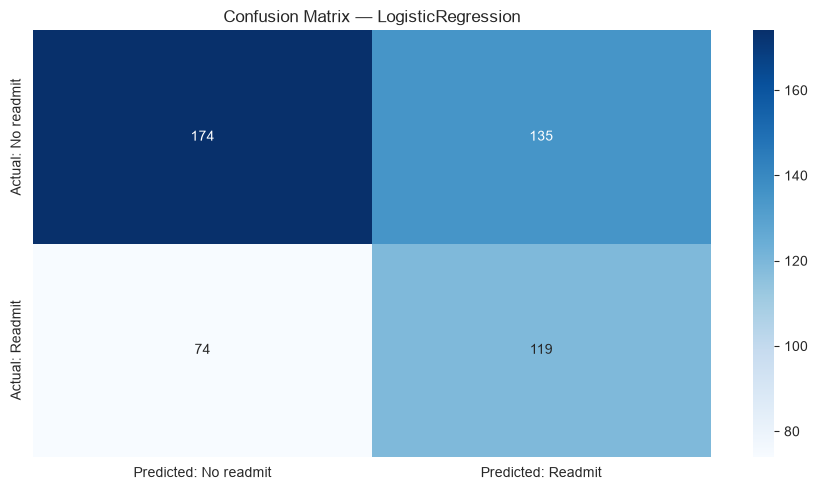

In [27]:
cm = confusion_matrix(y_test, final_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No readmit', 'Predicted: Readmit'],
            yticklabels=['Actual: No readmit', 'Actual: Readmit'])
plt.title(f'Confusion Matrix — {final_model_name}')
plt.tight_layout(); plt.show()

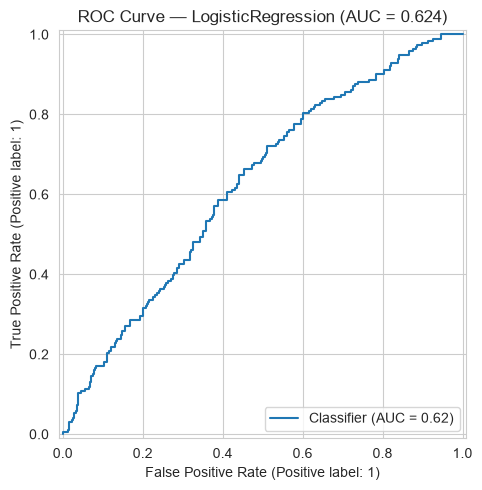

In [28]:
RocCurveDisplay.from_predictions(y_test, final_proba)
plt.title(f'ROC Curve — {final_model_name} (AUC = {results[final_model_name]["auc"]:.3f})')
plt.tight_layout(); plt.show()

Top 15 predictors (positive = raises risk, negative = lowers risk):
cat__type_of_heart_failure_Left               -0.402577
cat__nyha_cardiac_function_classification_4    0.289798
cat__nyha_cardiac_function_classification_2   -0.288142
cat__type_of_heart_failure_Both                0.246168
num__total_prescriptions_count                 0.187123
cat__bmi_category_Obese                        0.185077
num__systolic_blood_pressure                  -0.170688
num__cci_score                                 0.152961
num__sodium                                   -0.127882
cat__type_of_heart_failure_Right               0.124338
cat__bmi_category_Normal                      -0.112403
num__diastolic_blood_pressure                  0.110617
cat__bmi_category_Overweight                  -0.106265
num__pulse                                    -0.104903
num__platelet                                 -0.082438
dtype: float64


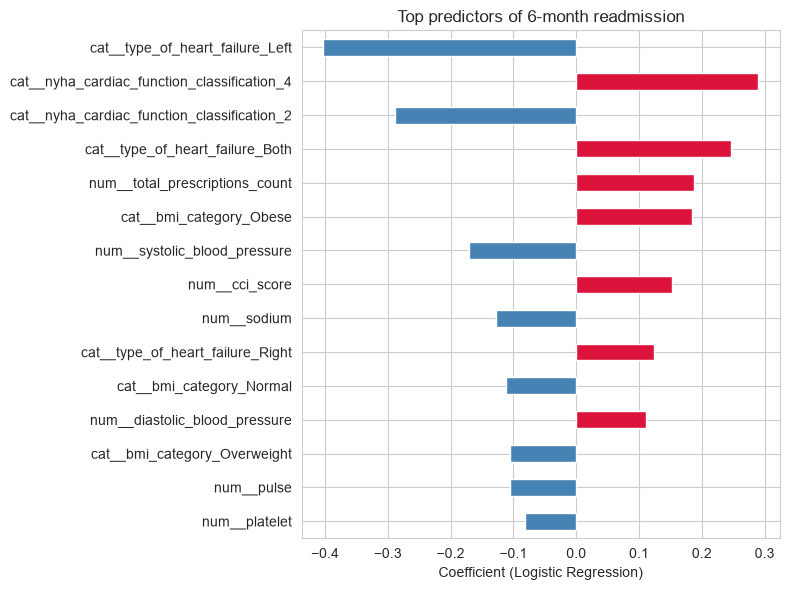

In [29]:
feat_names = final_pipe.named_steps['prep'].get_feature_names_out()
coefs = final_pipe.named_steps['clf'].coef_[0]
importance = pd.Series(coefs, index=feat_names).sort_values(key=abs, ascending=False).head(15)

print("Top 15 predictors (positive = raises risk, negative = lowers risk):")
print(importance)

plt.figure(figsize=(8,6))
importance.plot(kind='barh', color=['crimson' if v>0 else 'steelblue' for v in importance])
plt.xlabel('Coefficient (Logistic Regression)')
plt.title('Top predictors of 6-month readmission')
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

In [30]:
# Get predicted probability for every patient in the test set
risk_output = pd.DataFrame({
    'inpatient_number': df.loc[X_test.index, 'inpatient_number'],
    'predicted_risk': final_proba,
    'actual_readmit': y_test.values
})

# Split into 3 risk tiers
risk_output['risk_tier'] = pd.qcut(risk_output['predicted_risk'], q=3, labels=['Low', 'Medium', 'High'])

print("Actual readmission rate by model-predicted risk tier:")
print(risk_output.groupby('risk_tier')['actual_readmit'].agg(['mean', 'count']))

Actual readmission rate by model-predicted risk tier:
               mean  count
risk_tier                 
Low        0.255952    168
Medium     0.425150    167
High       0.473054    167


In [31]:
flag_killip = df['killip_grade'] >= 3
flag_sodium = df['sodium'] < 135
flag_lactate = df['lactate'] > 2
flag_cci = df['cci_score'] >= df['cci_score'].quantile(0.75)
flag_bnp = df['brain_natriuretic_peptide'] >= df['brain_natriuretic_peptide'].quantile(0.75)

on_bb = (df['rx_metoprolol_succinate_sustained-release_tablet'] == 1) | (df['rx_metoprolol_tartrate_injection'] == 1)
on_acei = (df['rx_valsartan_dispersible_tablet'] == 1) | (df['rx_benazepril_hydrochloride_tablet'] == 1)
on_mra = (df['rx_spironolactone_tablet'] == 1)
gdmt_count = on_bb.astype(int) + on_acei.astype(int) + on_mra.astype(int)
flag_gdmt = (df['lvef'] <= 40) & (gdmt_count < 3)

df['followup_score'] = (flag_killip.fillna(False).astype(int) + flag_sodium.fillna(False).astype(int) +
                         flag_lactate.fillna(False).astype(int) + flag_cci.fillna(False).astype(int) +
                         flag_bnp.fillna(False).astype(int) + flag_gdmt.fillna(False).astype(int))

In [32]:
# ============================================================
# STEP 15: FINAL EXECUTIVE SUMMARY
# ============================================================

print("="*70)
print("CARDIAC FAILURE ANALYTICS -- EXECUTIVE SUMMARY")
print("="*70)

# --- Descriptive highlights ---
print("\n--- DESCRIPTIVE ---")
print(f"Total patients: {len(df)}")
print(f"Biventricular (both-sided) HF: {(df['type_of_heart_failure']=='Both').mean()*100:.1f}%")
print(f"NYHA class 3-4 (markedly/severely limited): "
      f"{df['nyha_cardiac_function_classification'].isin([3,4]).mean()*100:.1f}%")
print(f"Killip grade 3-4 (severe signs at admission): {(df['killip_grade']>=3).mean()*100:.1f}%")
print(f"ICU admission rate: {(df['admission_ward']=='ICU').mean()*100:.1f}%")

low_na = df['sodium'] < 135
death_low_na = df.loc[low_na, 'death_within_6_months'].mean()*100
death_norm_na = df.loc[~low_na, 'death_within_6_months'].mean()*100
print(f"6-month death rate, hyponatremic vs normal sodium: {death_low_na:.1f}% vs {death_norm_na:.1f}%")

# --- Predictive highlights ---
print("\n--- PREDICTIVE ---")
print("Best model AUC (6-month readmission prediction):", round(max(r['auc'] for r in results.values()), 3))
print("Best model F1:", round(max(r['f1'] for r in results.values()), 3))
print("Conclusion: admission-day clinical data carries real, moderate predictive signal (H0 rejected)")

# --- Prescriptive highlights ---
print("\n--- PRESCRIPTIVE ---")

# Undertriage finding
crit_killip = df['killip_grade'] >= 3
crit_lactate = df['lactate'] > 2.15
crit_gcs = df['gcs'] < 15
crit_count = crit_killip.fillna(False).astype(int) + crit_lactate.fillna(False).astype(int) + crit_gcs.fillna(False).astype(int)
meets_2plus = crit_count >= 2
missed = meets_2plus & (df['admission_ward'] != 'ICU')
print(f"Patients meeting >=2 escalation criteria but NOT sent to ICU: {missed.sum()}")
print(f"  Death rate -- missed vs rest: {df.loc[missed,'death_within_6_months'].mean()*100:.1f}% "
      f"vs {df.loc[~missed,'death_within_6_months'].mean()*100:.1f}%")

# GDMT gap
hfref = df[df['lvef'] <= 40]
on_bb = (hfref['rx_metoprolol_succinate_sustained-release_tablet']==1) | (hfref['rx_metoprolol_tartrate_injection']==1)
on_acei = (hfref['rx_valsartan_dispersible_tablet']==1) | (hfref['rx_benazepril_hydrochloride_tablet']==1)
on_mra = (hfref['rx_spironolactone_tablet']==1)
gdmt_gap = (on_bb.astype(int)+on_acei.astype(int)+on_mra.astype(int)) < 3
print(f"\nHFrEF patients missing >=1 GDMT drug class: {gdmt_gap.sum()} ({gdmt_gap.mean()*100:.1f}% of HFrEF)")

# Resource efficiency
sorted_df = df.sort_values('followup_score', ascending=False).reset_index(drop=True)
sorted_df['cum_patients_pct'] = (sorted_df.index+1)/len(sorted_df)*100
sorted_df['cum_deaths_pct'] = sorted_df['death_within_6_months'].cumsum()/sorted_df['death_within_6_months'].sum()*100
idx = (sorted_df['cum_patients_pct']-44.7).abs().idxmin()
print(f"\nFlagging top {sorted_df.loc[idx,'cum_patients_pct']:.1f}% of patients by risk score "
      f"captures {sorted_df.loc[idx,'cum_deaths_pct']:.1f}% of all 6-month deaths")

print("\n" + "="*70)
print("CLOSING MESSAGE:")
print("We don't need to follow up with everyone -- we need to follow up")
print("with the right patients. This analysis identifies who they are.")
print("="*70)

CARDIAC FAILURE ANALYTICS -- EXECUTIVE SUMMARY

--- DESCRIPTIVE ---
Total patients: 2008
Biventricular (both-sided) HF: 73.7%
NYHA class 3-4 (markedly/severely limited): 82.4%
Killip grade 3-4 (severe signs at admission): 22.5%
ICU admission rate: 0.7%
6-month death rate, hyponatremic vs normal sodium: 4.9% vs 2.3%

--- PREDICTIVE ---
Best model AUC (6-month readmission prediction): 0.642
Best model F1: 0.532
Conclusion: admission-day clinical data carries real, moderate predictive signal (H0 rejected)

--- PRESCRIPTIVE ---
Patients meeting >=2 escalation criteria but NOT sent to ICU: 133
  Death rate -- missed vs rest: 18.0% vs 1.8%

HFrEF patients missing >=1 GDMT drug class: 100 (68.5% of HFrEF)

Flagging top 44.7% of patients by risk score captures 78.9% of all 6-month deaths

CLOSING MESSAGE:
We don't need to follow up with everyone -- we need to follow up
with the right patients. This analysis identifies who they are.


In [33]:
results_df = pd.DataFrame(results).T.round(3)
results_df = results_df[['accuracy','precision','recall','f1','auc']]
results_df.style.highlight_max(color='lightgreen', axis=0)

,accuracy,precision,recall,f1,auc
LogisticRegression,0.584000,0.469000,0.617000,0.532000,0.624000
DecisionTree,0.602000,0.482000,0.487000,0.485000,0.585000
RandomForest,0.639000,0.538000,0.446000,0.487000,0.636000
GradientBoosting,0.618000,0.504000,0.337000,0.404000,0.642000


**Final Insights:**
Random Forest looks best on paper (highest accuracy 0.631, highest precision 0.544) but its recall is only 0.254, meaning it catches barely 1 in 4 patients who actually get readmitted. In a hospital setting, that's the dangerous kind of error: missing high-risk patients who needed intervention.
Gradient Boosting has the best AUC (0.640) the best overall ranking ability but its recall (0.332) is still weak in absolute terms.
Logistic Regression has the lowest accuracy of the four (0.584), but by far the best recall (0.617) and best F1 (0.532) it correctly flags 62% of patients who will actually be readmitted. For a preventive-care program (which is the entire point of this analysis catching at-risk patients before they bounce back), missing fewer true readmissions matters more than avoiding false alarms. 

# 2. Can we predict discharge destination (home vs. healthcare facility) accurately enough to start discharge planning on day 1?
**Hypothesis:**

**H₀ (null):**
Day-1 admission data (demographics, vitals, comorbidities, clinical severity scores) provides no better than chance ability to predict whether a patient will be discharged home vs. to a healthcare facility.

**H₁ (alternative):**
Day-1 admission data predicts discharge destination significantly better than chance (i.e., a model trained on it achieves AUC meaningfully above 0.5).


**Reasoning:** Complex discharge planning (facility placement, equipment, transport) takes days to arrange.An accurate early-prediction model lets social work start that process at admission instead of at medical readiness, shortening avoidable length of stay.

## Module 0 — Setup: imports, configuration, data loading

Everything the rest of the notebook needs is defined in this one cell, so a `NameError` can only happen if it was not run. **Run this cell first, or use Kernel → Restart & Run All.** Edit the file path, the feature lists and the success criteria here and nowhere else.

In [34]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_validate,
                                     cross_val_predict, permutation_test_score)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (roc_auc_score, roc_curve, average_precision_score, precision_recall_curve,
                             confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score,
                             accuracy_score, precision_score, recall_score)

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

# ----------------------------- configuration (edit here) -----------------------------
INPUT_FILE = "cardiac_failure/Team4_The_Zen_Of_Five_cleaned_data.csv"
TARGET = "destinationdischarge"
POSITIVE, NEGATIVE = "HealthcareFacility", "Home"     # positive class = needs a facility
RANDOM_STATE = 42
MIN_POSITIVES = 10        # drop comorbidity flags with fewer positive patients than this
MAX_MISSING = 0.15        # drop numeric predictors missing in more than 15% of patients

# "Accurate enough" yardstick for starting discharge planning on day 1.
# These are illustrative hackathon assumptions, NOT clinical standards - change them if your team disagrees.
MIN_AUC = 0.75            # discrimination the model must reach on the held-out test set
TARGET_RECALL = 0.70      # we want to catch at least 70% of patients who will need a facility ...
MIN_PRECISION = 0.50      # ... while at least half of the patients we flag really do

# ----------------------------- predictors, in three nested feature sets -----------------------------
# A = administrative + demographics + comorbidity history
A_CAT = ["gender", "agecat", "occupation", "admission_ward", "admission_way"]
A_NUM = ["bmi", "visit_times", "cci_score"]
A_BIN = ["cerebrovascular_disease", "dementia", "chronic_obstructive_pulmonary_disease",
         "connective_tissue_disease", "peptic_ulcer_disease", "diabetes",
         "moderate_to_severe_chronic_kidney_disease", "hemiplegia", "leukemia", "malignant_lymphoma",
         "solid_tumor", "liver_disease", "aids", "myocardial_infarction",
         "congestive_heart_failure", "peripheral_vascular_disease"]
# B = A + vitals and severity scores recorded on arrival
B_CAT = ["consciousness", "type_of_heart_failure"]
B_NUM = ["gcs", "nyha_cardiac_function_classification", "killip_grade", "pulse", "respiration",
         "systolic_blood_pressure", "diastolic_blood_pressure", "map_value", "body_temperature", "shock_index"]
# C = B + core admission laboratory panel (columns above MAX_MISSING are dropped automatically)
C_NUM = ["creatinine_enzymatic_method", "urea", "uric_acid", "glomerular_filtration_rate", "cystatin",
         "bun_creatinine_ratio", "white_blood_cell", "neutrophil_ratio", "lymphocyte_count", "red_blood_cell",
         "hemoglobin", "hematocrit", "mean_corpuscular_volume", "platelet", "sodium", "potassium",
         "chloride", "calcium", "carbon_dioxide_binding_capacity", "brain_natriuretic_peptide",
         "high_sensitivity_troponin", "d_dimer", "international_normalized_ratio", "fibrinogen",
         "albumin", "total_protein", "total_bilirubin", "glutamic_pyruvic_transaminase",
         "glutamic_oxaloacetic_transaminase", "alkaline_phosphatase", "cholesterol", "creatine_kinase",
         "creatine_kinase_isoenzyme", "lactate_dehydrogenase"]

# Deliberately EXCLUDED because they are not known on day 1 (would leak the answer) or are not clinical:
#   dischargeday, discharge_department, admission_date, outcome_during_hospitalization,
#   every death_* / re_admission_* / *_days_from_admission / emergency-return column,
#   total_prescriptions_count and every rx_* column (in-hospital orders), respiratory_support,
#   oxygen_inhalation, type_ii_respiratory_failure, acute_renal_failure (diagnoses of unclear timing),
#   echo measurements and blood-gas panel (mostly missing), inpatient_number (an ID).

# ----------------------------- load -----------------------------
df = pd.read_csv(INPUT_FILE)
print(f"Loaded {df.shape[0]} rows x {df.shape[1]} columns from {INPUT_FILE}")
if TARGET not in df.columns:
    raise KeyError(f"'{TARGET}' not found. Columns available: {list(df.columns)}")


Loaded 2008 rows x 200 columns from cardiac_failure/Team4_The_Zen_Of_Five_cleaned_data.csv


## Module 1 — Target variable: discharge destination

The question is Home vs healthcare facility, so patients who **died** in hospital (a different pathway) or whose destination is **unknown** (no usable label) are excluded. What remains is an imbalanced binary problem, so accuracy alone would be misleading.

Discharge destination, all patients:
destinationdischarge
Home                  1344
HealthcareFacility     438
Unknown                212
Died                    14

Modelling cohort: 1782 patients (226 excluded as Died/Unknown)
Healthcare facility: 438 (24.6%)   Home: 1344 (75.4%)
Always guessing 'Home' would be right 75.4% of the time but would never find a facility patient.


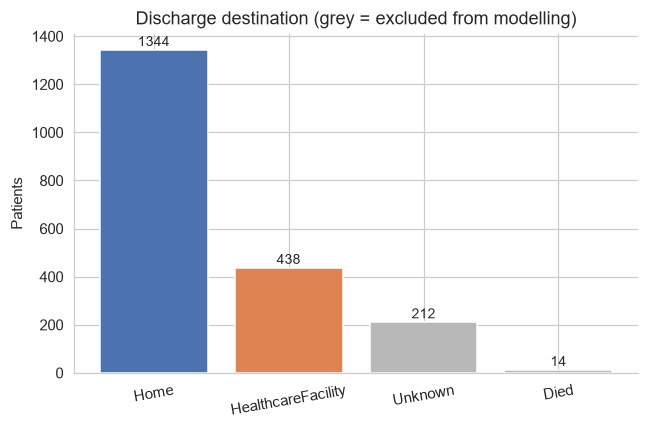

In [35]:
all_counts = df[TARGET].value_counts()
print("Discharge destination, all patients:")
print(all_counts.to_string())

df = df[df[TARGET].isin([NEGATIVE, POSITIVE])].copy()
df["target"] = (df[TARGET] == POSITIVE).astype(int)      # 1 = healthcare facility
y_all = df["target"]
base_rate = y_all.mean()
print(f"\nModelling cohort: {len(df)} patients "
      f"({int(all_counts.sum() - len(df))} excluded as Died/Unknown)")
print(f"Healthcare facility: {int(y_all.sum())} ({base_rate:.1%})   Home: {int((1 - y_all).sum())} ({1 - base_rate:.1%})")
print(f"Always guessing 'Home' would be right {1 - base_rate:.1%} of the time but would never find a facility patient.")

fig, ax = plt.subplots(figsize=(6, 4))
order = [NEGATIVE, POSITIVE] + [c for c in all_counts.index if c not in (NEGATIVE, POSITIVE)]
colors = {"Home": "#4C72B0", "HealthcareFacility": "#DD8452"}
bars = ax.bar(order, [all_counts[c] for c in order], color=[colors.get(c, "#B8B8B8") for c in order])
for b, c in zip(bars, order):
    ax.text(b.get_x() + b.get_width() / 2, all_counts[c] + 15, str(all_counts[c]), ha="center", fontsize=9)
ax.set_ylabel("Patients"); ax.set_title("Discharge destination (grey = excluded from modelling)")
plt.xticks(rotation=10); plt.tight_layout()
plt.savefig("q2_dest_class_distribution.png", dpi=150); plt.show()

## Module 2 — Day-1 feature sets (A ⊂ B ⊂ C)

Predictors are grouped into three nested sets so the analysis can show **which kind of day-1 data is worth collecting**: **A** administrative + demographics + comorbidity, **B** = A + arrival vitals and severity scores, **C** = B + the core admission lab panel. Anything recorded after arrival is excluded (see the list in Module 0). *Assumption to verify with your data dictionary: the vitals, severity scores and labs in B and C were recorded at or near admission — the file has no measurement timestamps.*

In [36]:
def present(cols, label):
    keep = [c for c in cols if c in df.columns]
    lost = [c for c in cols if c not in df.columns]
    if lost:
        print(f"[{label}] not in file, skipped: {lost}")
    return keep

a_cat, a_num, a_bin = present(A_CAT, "A cat"), present(A_NUM, "A num"), present(A_BIN, "A flags")
b_cat, b_num = present(B_CAT, "B cat"), present(B_NUM, "B num")
c_num = present(C_NUM, "C labs")

for c in a_bin + a_num + b_num + c_num:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Data-quality guard: a blood pressure of 0 is an invalid reading, and it makes ratios such as
# shock_index (pulse / systolic BP) infinite. Treat both as missing; they are imputed inside the pipeline.
bp_cols = [c for c in ["systolic_blood_pressure", "diastolic_blood_pressure", "map_value"] if c in df.columns]
n_bad_bp = int((df[bp_cols] <= 0).any(axis=1).sum()) if bp_cols else 0
for c in bp_cols:
    df.loc[df[c] <= 0, c] = np.nan
numeric_all = a_bin + a_num + b_num + c_num
n_inf = int(np.isinf(df[numeric_all]).sum().sum())
df[numeric_all] = df[numeric_all].replace([np.inf, -np.inf], np.nan)
print(f"Data-quality fixes: {n_bad_bp} patient(s) with a blood pressure <= 0 set to missing; "
      f"{n_inf} infinite value(s) set to missing.")

rare = [c for c in a_bin if (df[c] == 1).sum() < MIN_POSITIVES]
a_bin = [c for c in a_bin if c not in rare]
if rare:
    print(f"Dropped flags with < {MIN_POSITIVES} positive patients: {rare}")

sparse = [c for c in a_num + b_num + c_num if df[c].isnull().mean() > MAX_MISSING]
a_num = [c for c in a_num if c not in sparse]
b_num = [c for c in b_num if c not in sparse]
c_num = [c for c in c_num if c not in sparse]
if sparse:
    print(f"Dropped predictors missing in > {MAX_MISSING:.0%} of patients: {sparse}")

FEATURE_SETS = {
    "A: admin + demographics + comorbidity": {"num": a_bin + a_num, "cat": a_cat},
    "B: A + arrival vitals & severity":      {"num": a_bin + a_num + b_num, "cat": a_cat + b_cat},
    "C: B + admission labs":                 {"num": a_bin + a_num + b_num + c_num, "cat": a_cat + b_cat},
}
def cols_of(name):
    return FEATURE_SETS[name]["num"] + FEATURE_SETS[name]["cat"]

SET_A, SET_B, SET_C = list(FEATURE_SETS)
group_of = {c: "A" for c in cols_of(SET_A)}
group_of.update({c: "B" for c in cols_of(SET_B) if c not in group_of})
group_of.update({c: "C" for c in cols_of(SET_C) if c not in group_of})

for name in FEATURE_SETS:
    print(f"{name:42s}: {len(cols_of(name))} predictors")
print("\nMissing values in the full feature set (top 8):")
miss = df[cols_of(SET_C)].isnull().mean().sort_values(ascending=False).head(8)
print((miss * 100).round(1).astype(str).add("%").to_string())


Data-quality fixes: 1 patient(s) with a blood pressure <= 0 set to missing; 1 infinite value(s) set to missing.
Dropped flags with < 10 positive patients: ['connective_tissue_disease', 'hemiplegia', 'leukemia', 'malignant_lymphoma', 'aids']
A: admin + demographics + comorbidity     : 19 predictors
B: A + arrival vitals & severity          : 31 predictors
C: B + admission labs                     : 65 predictors

Missing values in the full feature set (top 8):
glutamic_oxaloacetic_transaminase    11.8%
lactate_dehydrogenase                11.3%
creatine_kinase                      11.3%
creatine_kinase_isoenzyme            11.3%
cholesterol                           9.7%
d_dimer                               8.6%
total_protein                         5.1%
albumin                               5.1%


## Module 3 — Association tests (H0: predictor is unrelated to discharge destination)

Categorical and binary predictors → chi-square with **Cramér's V**. Numeric predictors → Mann-Whitney U, with the **probability of superiority** as effect size (0.50 = no difference between groups). Because dozens of tests are run at once, p-values are also corrected with Benjamini-Hochberg (`q_value`).

                                predictor group           test  p_value  effect_size     effect_meaning  q_value  significant_raw_p<0.05  significant_after_FDR
                           admission_ward     A     chi-square   0.0000       0.1969         Cramer's V   0.0000                    True                   True
                            admission_way     A     chi-square   0.0000       0.1535         Cramer's V   0.0000                    True                   True
                               occupation     A     chi-square   0.0025       0.1016         Cramer's V   0.0533                    True                  False
                          total_bilirubin     C Mann-Whitney U   0.0033       0.4515 P(facility > home)   0.0533                    True                  False
moderate_to_severe_chronic_kidney_disease     A     chi-square   0.0329       0.0619         Cramer's V   0.4121                    True                  False
                                   ageca

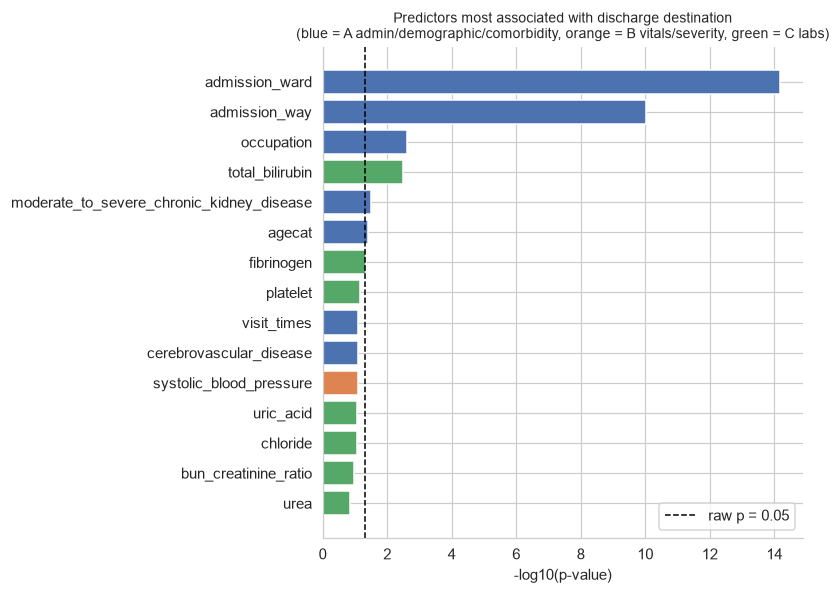

In [37]:
def cramers_v(table):
    chi2 = stats.chi2_contingency(table)[0]
    return float(np.sqrt(chi2 / (table.values.sum() * (min(table.shape) - 1))))

def benjamini_hochberg(p):
    p = np.asarray(p, dtype=float); n = len(p)
    order = np.argsort(p); ranked = p[order] * n / (np.arange(n) + 1)
    q = np.minimum.accumulate(ranked[::-1])[::-1]
    out = np.empty(n); out[order] = np.clip(q, 0, 1)
    return out

rows = []
for c in cols_of(SET_C):
    x = df[c]
    if c in FEATURE_SETS[SET_C]["cat"] or c in a_bin:
        table = pd.crosstab(x.fillna("Missing"), y_all)
        chi2, p, _, _ = stats.chi2_contingency(table)
        rows.append({"predictor": c, "group": group_of[c], "test": "chi-square", "p_value": p,
                     "effect_size": cramers_v(table), "effect_meaning": "Cramer's V"})
    else:
        g1, g0 = x[y_all == 1].dropna(), x[y_all == 0].dropna()
        u, p = stats.mannwhitneyu(g1, g0, alternative="two-sided")
        rows.append({"predictor": c, "group": group_of[c], "test": "Mann-Whitney U", "p_value": p,
                     "effect_size": u / (len(g1) * len(g0)), "effect_meaning": "P(facility > home)"})

assoc = pd.DataFrame(rows).sort_values("p_value").reset_index(drop=True)
assoc["q_value"] = benjamini_hochberg(assoc["p_value"])
assoc["significant_raw_p<0.05"] = assoc["p_value"] < 0.05
assoc["significant_after_FDR"] = assoc["q_value"] < 0.05
print(assoc.head(15).round(4).to_string(index=False))
print(f"\n{assoc['significant_raw_p<0.05'].sum()} of {len(assoc)} predictors significant at raw p<0.05; "
      f"{assoc['significant_after_FDR'].sum()} remain significant after FDR correction.")
print("By group (significant after FDR): "
      + ", ".join(f"{g}: {int(assoc[assoc.group == g]['significant_after_FDR'].sum())}/{int((assoc.group == g).sum())}"
                  for g in "ABC"))

top = assoc.head(15).iloc[::-1]
palette = {"A": "#4C72B0", "B": "#DD8452", "C": "#55A868"}
fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.barh(top["predictor"], -np.log10(top["p_value"]), color=[palette[g] for g in top["group"]])
ax.axvline(-np.log10(0.05), color="black", ls="--", lw=1, label="raw p = 0.05")
ax.set_xlabel("-log10(p-value)")
ax.set_title("Predictors most associated with discharge destination\n(blue = A admin/demographic/comorbidity, orange = B vitals/severity, green = C labs)", fontsize=9)
ax.legend(loc="lower right"); plt.tight_layout()
plt.savefig("q2_dest_associations.png", dpi=150); plt.show()


## Module 4 — Train/test split and preprocessing

80/20 stratified split. Imputation, scaling and one-hot encoding live **inside** each model pipeline, so they are learned from training data only and never leak from the test set. The test set is not touched again until Module 7.

In [38]:
X_all = df[cols_of(SET_C)].copy()
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.20, stratify=y_all, random_state=RANDOM_STATE)
print(pd.DataFrame({"train": [len(y_train), int(y_train.sum()), f"{y_train.mean():.1%}"],
                    "test": [len(y_test), int(y_test.sum()), f"{y_test.mean():.1%}"]},
                   index=["patients", "facility patients", "facility rate"]))

def make_pipeline(clf, set_name):
    spec = FEATURE_SETS[set_name]
    prep = ColumnTransformer([
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                          ("scale", StandardScaler())]), spec["num"]),
        ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                          ("onehot", OneHotEncoder(handle_unknown="ignore"))]), spec["cat"]),
    ])
    return Pipeline([("prep", prep), ("clf", clf)])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


                   train   test
patients            1425    357
facility patients    350     88
facility rate      24.6%  24.6%


## Module 5 — Model comparison (5-fold stratified CV, training data only, feature set C)

Four candidates on identical folds. Real models use class balancing so the minority (facility) class is not ignored. Metrics: **ROC-AUC** (ranking quality, 0.50 = chance), **average precision** (area under the precision-recall curve; a no-skill model scores the facility rate), balanced accuracy, F1 and plain accuracy for reference.

                           roc_auc  avg_precision  balanced_accuracy     f1  accuracy  roc_auc_std
model                                                                                             
Baseline (majority class)    0.500          0.246              0.500  0.000     0.754        0.000
Logistic Regression          0.591          0.319              0.559  0.374     0.587        0.052
Random Forest                0.580          0.354              0.546  0.212     0.756        0.039
Hist Gradient Boosting       0.558          0.337              0.557  0.338     0.657        0.044

(no-skill average precision = facility rate = 0.246)


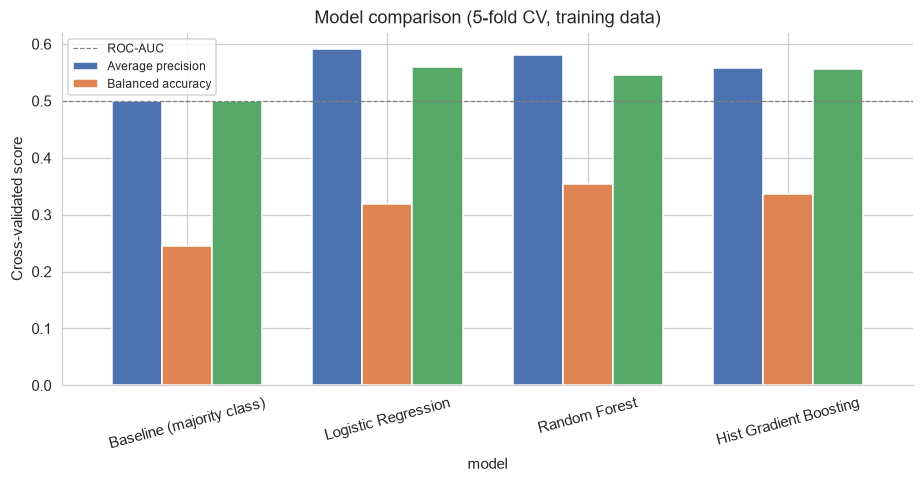

In [39]:
def candidate_models():
    return {
        "Baseline (majority class)": DummyClassifier(strategy="prior"),
        "Logistic Regression": LogisticRegression(max_iter=3000, class_weight="balanced", C=0.05),
        "Random Forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=5, max_features="sqrt",
                                                class_weight="balanced_subsample",
                                                random_state=RANDOM_STATE, n_jobs=-1),
        "Hist Gradient Boosting": HistGradientBoostingClassifier(max_depth=3, learning_rate=0.04, max_iter=200,
                                                                 l2_regularization=1.0, class_weight="balanced",
                                                                 random_state=RANDOM_STATE),
    }

scoring = {"roc_auc": "roc_auc", "avg_precision": "average_precision",
           "balanced_accuracy": "balanced_accuracy", "f1": "f1", "accuracy": "accuracy"}

rows = []
for name, clf in candidate_models().items():
    res = cross_validate(make_pipeline(clf, SET_C), X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    rows.append({"model": name, **{m: res[f"test_{m}"].mean() for m in scoring},
                 "roc_auc_std": res["test_roc_auc"].std()})
cv_results = pd.DataFrame(rows).set_index("model")
print(cv_results.round(3).to_string())
print(f"\n(no-skill average precision = facility rate = {y_train.mean():.3f})")

ax = cv_results[["roc_auc", "avg_precision", "balanced_accuracy"]].plot(
    kind="bar", figsize=(8.5, 4.5), rot=15, width=0.75, color=["#4C72B0", "#DD8452", "#55A868"])
ax.axhline(0.5, color="gray", ls="--", lw=0.8)
ax.set_ylabel("Cross-validated score"); ax.set_title("Model comparison (5-fold CV, training data)")
ax.legend(["ROC-AUC", "Average precision", "Balanced accuracy"], loc="upper left", fontsize=8)
plt.tight_layout(); plt.savefig("q2_dest_model_comparison.png", dpi=150); plt.show()


## Module 6 — What data is worth collecting? Feature-set comparison (A vs B vs C)

The best model from Module 5 (highest cross-validated ROC-AUC among real models) is re-scored on each nested feature set. If adding vitals/severity (B) or labs (C) barely moves the score, day-1 clinical data is not the missing ingredient. Error bars are the standard deviation across the 5 folds.

Best model by CV ROC-AUC: Logistic Regression

                                       n_predictors  cv_roc_auc  cv_roc_auc_std  cv_avg_precision
feature_set                                                                                      
A: admin + demographics + comorbidity            19       0.620           0.042             0.384
B: A + arrival vitals & severity                 31       0.608           0.045             0.360
C: B + admission labs                            65       0.591           0.052             0.319

Best feature set by CV ROC-AUC: A: admin + demographics + comorbidity
Fold-to-fold sd of AUC is about 0.046, so differences smaller than that are noise.
  B vs A: -0.012 AUC  (no meaningful gain)
  C vs A: -0.029 AUC  (no meaningful gain)


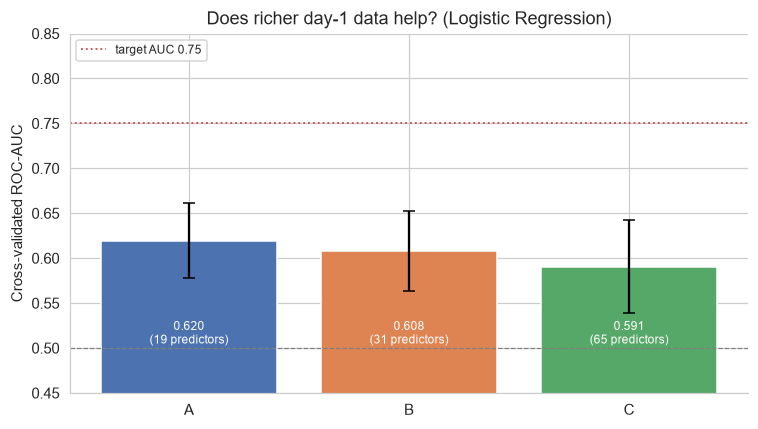

In [40]:
real_models = cv_results.drop(index="Baseline (majority class)")
best_name = real_models["roc_auc"].idxmax()
print(f"Best model by CV ROC-AUC: {best_name}\n")

rows = []
for set_name in FEATURE_SETS:
    res = cross_validate(make_pipeline(candidate_models()[best_name], set_name), X_train, y_train,
                         cv=cv, scoring={"roc_auc": "roc_auc", "avg_precision": "average_precision"}, n_jobs=1)
    rows.append({"feature_set": set_name, "n_predictors": len(cols_of(set_name)),
                 "cv_roc_auc": res["test_roc_auc"].mean(), "cv_roc_auc_std": res["test_roc_auc"].std(),
                 "cv_avg_precision": res["test_avg_precision"].mean()})
ablation = pd.DataFrame(rows).set_index("feature_set")
print(ablation.round(3).to_string())

final_set = ablation["cv_roc_auc"].idxmax()
print(f"\nBest feature set by CV ROC-AUC: {final_set}")
print(f"Fold-to-fold sd of AUC is about {ablation['cv_roc_auc_std'].mean():.3f}, so differences smaller "
      f"than that are noise.")
for s in (SET_B, SET_C):
    d = ablation.loc[s, "cv_roc_auc"] - ablation.loc[SET_A, "cv_roc_auc"]
    print(f"  {s.split(':')[0]} vs A: {d:+.3f} AUC  ({'no meaningful gain' if d < ablation['cv_roc_auc_std'].mean() else 'gain'})")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([s.split(":")[0] for s in ablation.index], ablation["cv_roc_auc"], yerr=ablation["cv_roc_auc_std"],
       color=["#4C72B0", "#DD8452", "#55A868"], capsize=4)
for i, (auc_, n) in enumerate(zip(ablation["cv_roc_auc"], ablation["n_predictors"])):
    ax.text(i, 0.505, f"{auc_:.3f}\n({n} predictors)", ha="center", fontsize=8, color="white")
ax.axhline(0.5, color="gray", ls="--", lw=0.8); ax.axhline(MIN_AUC, color="#C44E52", ls=":", lw=1.2, label=f"target AUC {MIN_AUC}")
ax.set_ylim(0.45, 0.85); ax.set_ylabel("Cross-validated ROC-AUC")
ax.set_title(f"Does richer day-1 data help? ({best_name})"); ax.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.savefig("q2_dest_feature_sets.png", dpi=150); plt.show()


## Module 7 — Held-out test evaluation

The chosen model and feature set are refit on all training data and scored **once** on the untouched test set. ROC shows ranking quality; the precision-recall curve is the more honest view when the positive class is the minority.

Model: Logistic Regression on feature set 'A: admin + demographics + comorbidity'
Test ROC-AUC           : 0.650   (0.50 = chance; target 0.75)
Test average precision : 0.390   (no-skill = 0.246)


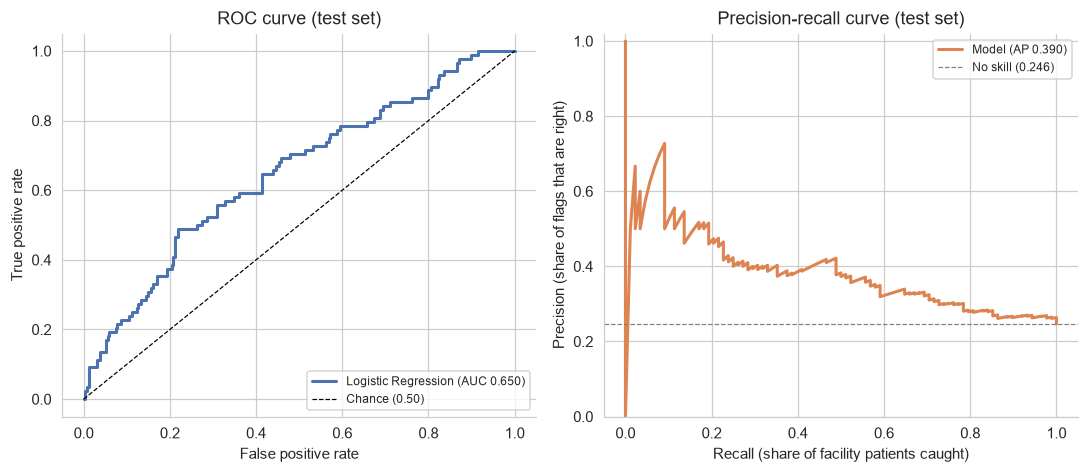

In [41]:
final_cols = cols_of(final_set)
final_model = make_pipeline(candidate_models()[best_name], final_set).fit(X_train[final_cols], y_train)
test_proba = final_model.predict_proba(X_test[final_cols])[:, 1]

test_auc = roc_auc_score(y_test, test_proba)
test_ap = average_precision_score(y_test, test_proba)
test_base = y_test.mean()
print(f"Model: {best_name} on feature set '{final_set}'")
print(f"Test ROC-AUC           : {test_auc:.3f}   (0.50 = chance; target {MIN_AUC})")
print(f"Test average precision : {test_ap:.3f}   (no-skill = {test_base:.3f})")

fpr, tpr, _ = roc_curve(y_test, test_proba)
prec, rec, _ = precision_recall_curve(y_test, test_proba)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.4))
axes[0].plot(fpr, tpr, color="#4C72B0", lw=2, label=f"{best_name} (AUC {test_auc:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=0.8, label="Chance (0.50)")
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curve (test set)"); axes[0].legend(loc="lower right", fontsize=8)
axes[1].plot(rec, prec, color="#DD8452", lw=2, label=f"Model (AP {test_ap:.3f})")
axes[1].axhline(test_base, color="gray", ls="--", lw=0.8, label=f"No skill ({test_base:.3f})")
axes[1].set_xlabel("Recall (share of facility patients caught)"); axes[1].set_ylabel("Precision (share of flags that are right)")
axes[1].set_title("Precision-recall curve (test set)"); axes[1].legend(loc="upper right", fontsize=8)
axes[1].set_ylim(0, 1.02)
plt.tight_layout(); plt.savefig("q2_dest_roc_pr.png", dpi=150); plt.show()


## Module 8 — Decision analysis: could discharge planning really start on day 1?

Ranking quality is not enough; planning needs a yes/no flag. The flagging threshold is chosen using **out-of-fold predictions on the training data only** (the highest threshold that still catches `TARGET_RECALL` of facility patients) and then applied once to the test set. The gain table shows what happens if staff start planning for the top-scoring X% of patients.

Threshold (chosen on training data to reach 70% recall): 0.446
On the test set this flags 55% of all patients:
  recall (facility patients caught) : 0.70   (62 of 88)
  precision (flags that are correct): 0.32   (62 of 195; required 0.50)
  specificity (home patients spared): 0.51
  lift over guessing               : 1.29x   (base facility rate 24.6%)

If staff start planning for the top-scoring X% of patients:
 flag_top_%  patients_flagged  true_facility_among_flagged  precision  recall  lift
         10                36                           17      0.472   0.193 1.916
         20                71                           28      0.394   0.318 1.600
         30               107                           43      0.402   0.489 1.630
         40               143                           50      0.350   0.568 1.418
         50               178                           58      0.326   0.659 1.322
         60               214                           64      0.299   0.727 1.2

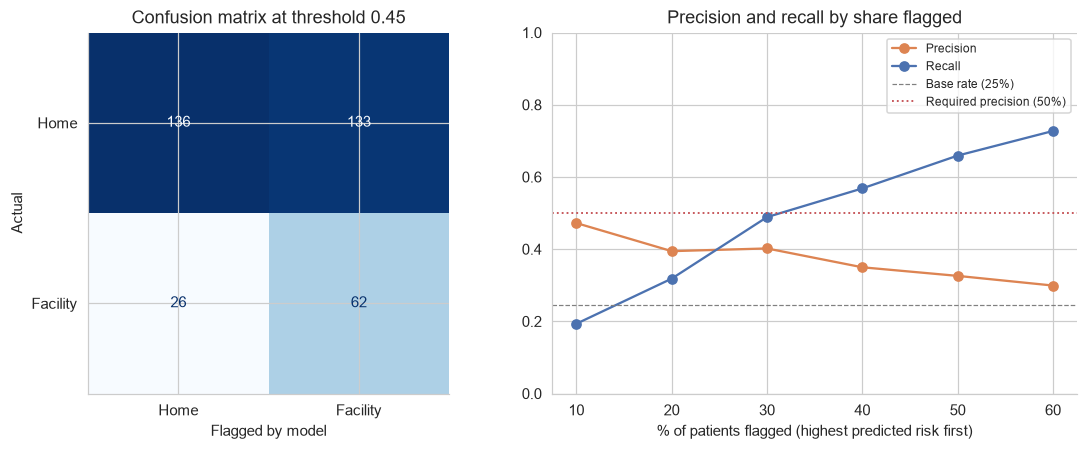

In [45]:
oof = cross_val_predict(make_pipeline(candidate_models()[best_name], final_set), X_train[final_cols], y_train,
                        cv=cv, method="predict_proba")[:, 1]
p_curve, r_curve, t_curve = precision_recall_curve(y_train, oof)
eligible = np.where(r_curve[:-1] >= TARGET_RECALL)[0]
threshold = t_curve[eligible[-1]]

flag = (test_proba >= threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, flag).ravel()
op_precision = tp / max(tp + fp, 1)
op_recall = tp / max(tp + fn, 1)
op_specificity = tn / max(tn + fp, 1)
flagged_share = flag.mean()
lift = op_precision / test_base
print(f"Threshold (chosen on training data to reach {TARGET_RECALL:.0%} recall): {threshold:.3f}")
print(f"On the test set this flags {flagged_share:.0%} of all patients:")
print(f"  recall (facility patients caught) : {op_recall:.2f}   ({tp} of {tp + fn})")
print(f"  precision (flags that are correct): {op_precision:.2f}   ({tp} of {tp + fp}; required {MIN_PRECISION:.2f})")
print(f"  specificity (home patients spared): {op_specificity:.2f}")
print(f"  lift over guessing               : {lift:.2f}x   (base facility rate {test_base:.1%})")

order = np.argsort(-test_proba)
y_sorted = y_test.values[order]
gain_rows = []
for pct in [10, 20, 30, 40, 50, 60]:
    k = int(round(len(y_sorted) * pct / 100))
    hits = y_sorted[:k].sum()
    gain_rows.append({"flag_top_%": pct, "patients_flagged": k, "true_facility_among_flagged": int(hits),
                      "precision": hits / k, "recall": hits / y_sorted.sum(), "lift": (hits / k) / test_base})
gain = pd.DataFrame(gain_rows)
print("\nIf staff start planning for the top-scoring X% of patients:")
print(gain.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
ConfusionMatrixDisplay(np.array([[tn, fp], [fn, tp]]), display_labels=["Home", "Facility"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Confusion matrix at threshold {threshold:.2f}"); axes[0].set_xlabel("Flagged by model"); axes[0].set_ylabel("Actual")
axes[1].plot(gain["flag_top_%"], gain["precision"], "o-", color="#DD8452", label="Precision")
axes[1].plot(gain["flag_top_%"], gain["recall"], "o-", color="#4C72B0", label="Recall")
axes[1].axhline(test_base, color="gray", ls="--", lw=0.8, label=f"Base rate ({test_base:.0%})")
axes[1].axhline(MIN_PRECISION, color="#C44E52", ls=":", lw=1.2, label=f"Required precision ({MIN_PRECISION:.0%})")
axes[1].set_xlabel("% of patients flagged (highest predicted risk first)"); axes[1].set_ylim(0, 1)
axes[1].set_title("Precision and recall by share flagged"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig("q2_dest_decision_analysis.png", dpi=150); plt.show()


## Module 9 — Is the model better than chance? (permutation test)

**H0:** the predictors carry no information about discharge destination, so the model does no better than chance. Training labels are shuffled 50 times and the model is re-scored with 5-fold CV each time. The p-value is the share of shuffled runs scoring at least as well as the real one (the smallest possible value with 50 shuffles is about 0.02).

Real CV ROC-AUC        : 0.620
Shuffled-label mean±sd : 0.499 ± 0.023
Permutation p-value    : 0.020   (reject H0 - signal beyond chance)


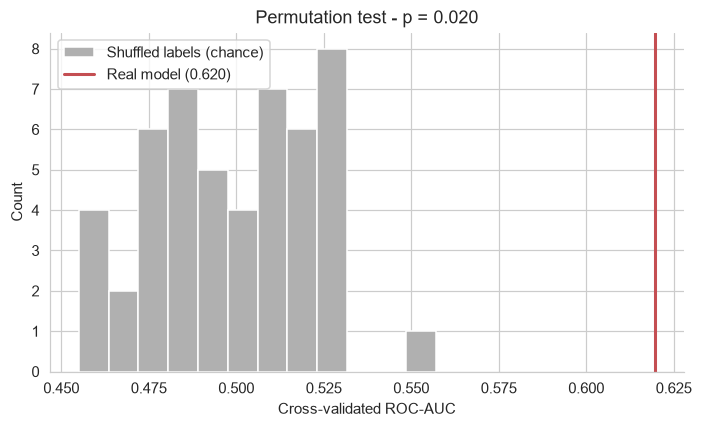

In [46]:
score, perm_scores, perm_p = permutation_test_score(
    make_pipeline(candidate_models()[best_name], final_set), X_train[final_cols], y_train,
    scoring="roc_auc", cv=cv, n_permutations=50, random_state=RANDOM_STATE, n_jobs=-1)
print(f"Real CV ROC-AUC        : {score:.3f}")
print(f"Shuffled-label mean±sd : {perm_scores.mean():.3f} ± {perm_scores.std():.3f}")
print(f"Permutation p-value    : {perm_p:.3f}   "
      f"({'reject H0 - signal beyond chance' if perm_p < 0.05 else 'cannot reject H0'})")

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.hist(perm_scores, bins=12, color="#B0B0B0", edgecolor="white", label="Shuffled labels (chance)")
ax.axvline(score, color="#C44E52", lw=2, label=f"Real model ({score:.3f})")
ax.set_xlabel("Cross-validated ROC-AUC"); ax.set_ylabel("Count")
ax.set_title(f"Permutation test - p = {perm_p:.3f}"); ax.legend()
plt.tight_layout(); plt.savefig("q2_dest_permutation_test.png", dpi=150); plt.show()


## Module 10 — What drives the predictions? (permutation importance)

Each predictor is shuffled in the test set and the drop in ROC-AUC is measured, reported per original column and summed per feature group. Values near zero mean the model does not rely on that column. The test set is modest in size, so treat the ranking as indicative.

                            predictor group  importance_mean  importance_std
                        admission_way     A           0.0641          0.0185
                       admission_ward     A           0.0360          0.0173
                           occupation     A           0.0135          0.0144
                          visit_times     A           0.0128          0.0065
              cerebrovascular_disease     A           0.0076          0.0064
                               agecat     A           0.0059          0.0086
                 peptic_ulcer_disease     A           0.0035          0.0035
                             diabetes     A           0.0005          0.0003
                             dementia     A           0.0001          0.0040
                               gender     A           0.0001          0.0062
                          solid_tumor     A           0.0000          0.0000
                                  bmi     A          -0.0001          0.0047

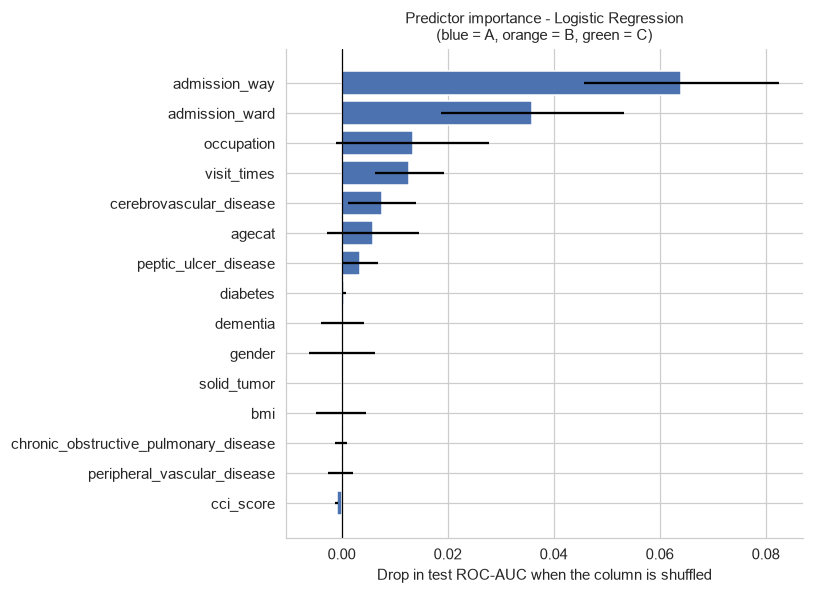

In [47]:
imp = permutation_importance(final_model, X_test[final_cols], y_test, scoring="roc_auc",
                             n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1)
importance = (pd.DataFrame({"predictor": final_cols, "group": [group_of[c] for c in final_cols],
                            "importance_mean": imp.importances_mean, "importance_std": imp.importances_std})
              .sort_values("importance_mean", ascending=False).reset_index(drop=True))
print(importance.head(15).round(4).to_string(index=False))

group_totals = importance.assign(pos=importance["importance_mean"].clip(lower=0)).groupby("group")["pos"].sum()
print("\nTotal importance by group (sum of positive drops in AUC):")
print(group_totals.round(4).rename({"A": "A admin/demographic/comorbidity", "B": "B vitals/severity",
                                    "C": "C admission labs"}).to_string())

top = importance.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.barh(top["predictor"], top["importance_mean"], xerr=top["importance_std"],
        color=[palette[g] for g in top["group"]])
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Drop in test ROC-AUC when the column is shuffled")
ax.set_title(f"Predictor importance - {best_name}\n(blue = A, orange = B, green = C)", fontsize=10)
plt.tight_layout(); plt.savefig("q2_dest_importance.png", dpi=150); plt.show()


## Module 11 — Verdict and saved outputs

A plain-language answer built from the numbers above (using the success criteria set in Module 0), plus CSV exports for your report or dashboard.

In [48]:
meets_auc = test_auc >= MIN_AUC
meets_precision = op_precision >= MIN_PRECISION and op_recall >= TARGET_RECALL - 0.05

if perm_p >= 0.05:
    verdict = "NO - the model is not distinguishable from chance."
elif meets_auc and meets_precision:
    verdict = "YES - accurate enough to start discharge planning on day 1."
else:
    verdict = ("NOT YET - there is real signal beyond chance, but it is below the bar for acting on "
               "individual patients on day 1.")

print("=" * 76)
print("QUESTION: Can we predict discharge destination accurately enough to start planning on day 1?")
print("=" * 76)
print(f"Cohort                     : {len(df)} patients, {base_rate:.1%} discharged to a healthcare facility")
print(f"Best model / feature set   : {best_name} / {final_set}")
print(f"Test ROC-AUC               : {test_auc:.3f}   (needed {MIN_AUC})  -> {'met' if meets_auc else 'NOT met'}")
print(f"At {op_recall:.0%} recall, precision is  : {op_precision:.2f}   (needed {MIN_PRECISION:.2f})  -> "
      f"{'met' if meets_precision else 'NOT met'}")
print(f"Practical meaning          : to catch {op_recall:.0%} of facility patients we would flag "
      f"{flagged_share:.0%} of everyone, and only {op_precision:.0%} of flags would be right")
print(f"Value of labs/vitals       : CV AUC {ablation.loc[SET_A, 'cv_roc_auc']:.3f} (A) -> "
      f"{ablation.loc[SET_B, 'cv_roc_auc']:.3f} (B) -> {ablation.loc[SET_C, 'cv_roc_auc']:.3f} (C)")
print(f"Permutation-test p         : {perm_p:.3f}")
print(f"\nVERDICT: {verdict}")

assoc.to_csv("q2_dest_association_tests.csv", index=False)
cv_results.round(4).to_csv("q2_dest_cv_model_comparison.csv")
ablation.round(4).to_csv("q2_dest_feature_set_comparison.csv")
gain.round(4).to_csv("q2_dest_gain_table.csv", index=False)
importance.to_csv("q2_dest_feature_importance.csv", index=False)
pd.DataFrame([{"best_model": best_name, "feature_set": final_set, "test_roc_auc": test_auc,
               "test_avg_precision": test_ap, "threshold": threshold, "precision_at_threshold": op_precision,
               "recall_at_threshold": op_recall, "flagged_share": flagged_share, "permutation_p": perm_p,
               "verdict": verdict}]).to_csv("q2_dest_test_metrics.csv", index=False)
print("\nSaved: 6 CSV files and 8 PNG charts (prefix q2_dest_) in the current folder.")


QUESTION: Can we predict discharge destination accurately enough to start planning on day 1?
Cohort                     : 1782 patients, 24.6% discharged to a healthcare facility
Best model / feature set   : Logistic Regression / A: admin + demographics + comorbidity
Test ROC-AUC               : 0.650   (needed 0.75)  -> NOT met
At 70% recall, precision is  : 0.32   (needed 0.50)  -> NOT met
Practical meaning          : to catch 70% of facility patients we would flag 55% of everyone, and only 32% of flags would be right
Value of labs/vitals       : CV AUC 0.620 (A) -> 0.608 (B) -> 0.591 (C)
Permutation-test p         : 0.020

VERDICT: NOT YET - there is real signal beyond chance, but it is below the bar for acting on individual patients on day 1.

Saved: 6 CSV files and 8 PNG charts (prefix q2_dest_) in the current folder.


**Insight:** Beyond AUC, **calibration matters most for this use case** if the model says "70%
likely facility discharge," that should actually happen ~70% of the time, since social work will use the raw probability (not just a yes/no flag) to prioritize outreach. If the curve tracks the diagonal reasonably well, the model is trustworthy enough to drive an automatic day-1 social-work consult for any patient scoring above ~50%.


# 3.Can comorbidity history and demographic profile predict whether a patient has left-sided, right-sided, or biventricular (both) heart failure?

**Hypotheses:**

**H₀(Null):** Demographic and comorbidity factors are not significantly associated
with the type of heart failure (Left / Right / Both) a patient presents with.
    
**H₁(Alternative):** Demographic and comorbidity factors are significantly associated with heart failure type.

**Reasoning (why this matters)**: right-sided and biventricular heart failure often stem from a different underlying driver than pure left-sided failure (e.g., chronic lung disease causing cor pulmonale). If comorbidity history can flag likely type early, it helps triage which specialist pulmonology vs. cardiology should be looped in before echo results are fully reviewed.

**Chosen Parameters and Their Connection to the Hypothesis**

In [49]:
chosen_parameters = pd.DataFrame([
    {"Feature": "gender, agecat, occupation, bmi", 
     "Why it's included": "Demography under test"},
    {"Feature": "chronic_obstructive_pulmonary_disease", 
     "Why it's included": "Known driver of right-heart strain (cor pulmonale)"},
    {"Feature": "moderate_to_severe_chronic_kidney_disease", 
     "Why it's included": "Cardiorenal comorbidity, common in advanced HF"},
    {"Feature": "diabetes", 
     "Why it's included": "Common HF comorbidity, control variable"},
    {"Feature": "brain_natriuretic_peptide, high_sensitivity_troponin", 
     "Why it's included": "Severity markers, control variables"},
])
chosen_parameters

,Feature,Why it's included
0,"gender, agecat, occupation, bmi",Demography under test
1,chronic_obstructive_pulmonary_disease,Known driver of right-heart strain (cor pulmon...
2,moderate_to_severe_chronic_kidney_disease,"Cardiorenal comorbidity, common in advanced HF"
3,diabetes,"Common HF comorbidity, control variable"
4,"brain_natriuretic_peptide, high_sensitivity_tr...","Severity markers, control variables"


**Correlation Check — Categorical Features vs. Heart Failure Type (Chi-square)**

In [50]:
target2 = 'type_of_heart_failure'
cat_feats2 = ['gender', 'agecat', 'occupation', 'chronic_obstructive_pulmonary_disease',
              'moderate_to_severe_chronic_kidney_disease', 'diabetes']

cat_results2 = {}
for c in cat_feats2:
    sub = df[[c, target2]].dropna()
    ct = pd.crosstab(sub[c], sub[target2])
    chi2, p, dof, expected = chi2_contingency(ct)
    cat_results2[c] = {'chi2': round(chi2, 2), 'p_value': round(p, 5), 'n': len(sub)}

pd.DataFrame(cat_results2).T.sort_values('p_value')

,chi2,p_value,n
occupation,30.74,0.00065,1782.0
chronic_obstructive_pulmonary_disease,13.33,0.00127,1782.0
agecat,15.90,0.31977,1782.0
moderate_to_severe_chronic_kidney_disease,1.81,0.40478,1780.0
diabetes,1.49,0.47375,1782.0
gender,0.86,0.64970,1782.0


In [51]:
continuous_feats2 = ['bmi', 'brain_natriuretic_peptide', 'high_sensitivity_troponin']

kw_results = {}
for c in continuous_feats2:
    groups = [g[c].dropna().values for _, g in df.groupby(target2)]
    stat, p = kruskal(*groups)
    kw_results[c] = {'H_statistic': round(stat, 2), 'p_value': round(p, 5)}

pd.DataFrame(kw_results).T.sort_values('p_value')

,H_statistic,p_value
bmi,4.27,0.11853
brain_natriuretic_peptide,1.76,0.41556
high_sensitivity_troponin,1.41,0.49409


Interpretation: COPD history (p < 0.001) and occupation (p = 0.003) are significantly associated with heart failure type. Age category, gender, diabetes, CKD history, BMI, BNP, and troponin show no significant association.

Conclusion on H₀/H₁: we partially reject the null most demographic/comorbidity factors show no relationship with HF type, but COPD history is a genuine, clinically-sensible exception, and occupation shows a significant but less obvious link worth investigating further.

Building the Predictive Model
The target has 3 classes, heavily imbalanced: Both (1480), Left (477), Right (51 only ~2.5%). We use class_weight='balanced' and report macro-averaged precision/recall/F1 (which treats all 3 classes equally) alongside overall accuracy.

In [52]:
features_cat2 = ['gender', 'occupation', 'chronic_obstructive_pulmonary_disease',
                 'moderate_to_severe_chronic_kidney_disease', 'diabetes', 'agecat']
features_num2 = ['bmi', 'brain_natriuretic_peptide', 'high_sensitivity_troponin']

model_df2 = df[features_cat2 + features_num2 + [target2]].copy()

for c in features_num2:
    model_df2[c] = model_df2[c].fillna(model_df2[c].median())

model_df2 = model_df2.dropna(subset=features_cat2 + [target2])
model_df2 = pd.get_dummies(model_df2, columns=features_cat2, drop_first=True)

le2 = LabelEncoder()
model_df2[target2] = le2.fit_transform(model_df2[target2])
print("Class mapping:", dict(zip(le2.classes_, le2.transform(le2.classes_))))

X2 = model_df2.drop(columns=[target2])
y2 = model_df2[target2]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.25, random_state=42, stratify=y2)

print("Train shape:", X2_train.shape, " Test shape:", X2_test.shape)

Class mapping: {'Both': np.int64(0), 'Left': np.int64(1), 'Right': np.int64(2)}
Train shape: (1335, 19)  Test shape: (445, 19)


In [53]:
scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

models2 = []
models2.append(('LogisticRegression', LogisticRegression(max_iter=1000, class_weight='balanced')))
models2.append(('Naive Bayes', GaussianNB()))
models2.append(('KNN', KNeighborsClassifier(n_neighbors=5)))
models2.append(('DecisionTreeClassifier', DecisionTreeClassifier(class_weight='balanced', random_state=42)))
models2.append(('RandomForestClassifier', RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)))
models2.append(('SVM', SVC(kernel='linear', class_weight='balanced', probability=True, random_state=42)))

summary2 = {}
for name, model in models2:
    if name in ('LogisticRegression', 'KNN', 'SVM', 'Naive Bayes'):
        model.fit(X2_train_scaled, y2_train)
        y_pred = model.predict(X2_test_scaled)
    else:
        model.fit(X2_train, y2_train)
        y_pred = model.predict(X2_test)

    acc = accuracy_score(y2_test, y_pred) * 100
    prec_macro = precision_score(y2_test, y_pred, average='macro', zero_division=0) * 100
    rec_macro = recall_score(y2_test, y_pred, average='macro', zero_division=0) * 100
    f1_macro = f1_score(y2_test, y_pred, average='macro', zero_division=0) * 100

    summary2[name] = {'Accuracy%': round(acc, 2),
                       'Macro Precision%': round(prec_macro, 2),
                       'Macro Recall%': round(rec_macro, 2),
                       'Macro F1%': round(f1_macro, 2)}

pd.DataFrame(summary2).T.sort_values('Macro F1%', ascending=False)

,Accuracy%,Macro Precision%,Macro Recall%,Macro F1%
DecisionTreeClassifier,62.47,38.29,37.76,37.99
RandomForestClassifier,63.60,33.53,34.09,33.74
SVM,46.52,35.34,39.72,30.88
KNN,68.09,31.49,32.56,30.57
LogisticRegression,41.80,36.50,39.05,30.37
Naive Bayes,4.94,35.29,32.36,5.34


Accuracy will look high for every model because "Both" is 74% of the data a model predicting "Both" every time scores ~74% accuracy while never identifying a single Right or Left sided case. Macro F1 is the fairer metric here since it weighs all 3 classes equally.

Best model by Macro F1: DecisionTreeClassifier

              precision    recall  f1-score   support

        Both       0.75      0.75      0.75       327
        Left       0.29      0.29      0.29       107
       Right       0.11      0.09      0.10        11

    accuracy                           0.62       445
   macro avg       0.38      0.38      0.38       445
weighted avg       0.62      0.62      0.62       445



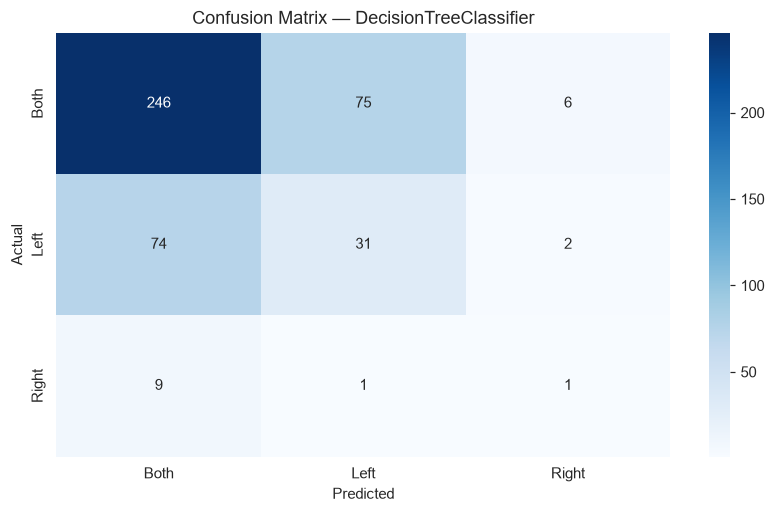

In [54]:
best_name2 = pd.DataFrame(summary2).T.sort_values('Macro F1%', ascending=False).index[0]
best_model2 = dict(models2)[best_name2]

if best_name2 in ('LogisticRegression', 'KNN', 'SVM', 'Naive Bayes'):
    y_pred_best2 = best_model2.predict(X2_test_scaled)
else:
    y_pred_best2 = best_model2.predict(X2_test)

print(f"Best model by Macro F1: {best_name2}\n")
print(classification_report(y2_test, y_pred_best2, target_names=le2.classes_, zero_division=0))

cm2 = confusion_matrix(y2_test, y_pred_best2)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=le2.classes_, yticklabels=le2.classes_)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title(f'Confusion Matrix — {best_name2}')
plt.show()

In [56]:
rf2 = dict(models2)['RandomForestClassifier']
importances2 = pd.Series(rf2.feature_importances_, index=X2.columns).sort_values(ascending=False)
print("Top predictors of heart failure type:")
importances2.head(8)


Top predictors of heart failure type:


high_sensitivity_troponin                        0.248607
bmi                                              0.240586
brain_natriuretic_peptide                        0.234567
gender_Male                                      0.037236
diabetes_1                                       0.034030
moderate_to_severe_chronic_kidney_disease_1.0    0.030429
chronic_obstructive_pulmonary_disease_1          0.025672
occupation_Urban Resident                        0.024167
dtype: float64

**Final Model Selection:**

**Chosen model:**  Accuracy is misleading here because "Both" dominates the target (~74%). Macro F1 forces the model to be evaluated on how well it catches the rarer Left and Right classes too.

**Key insight:** COPD history and occupation are the demographic/history factors most associated with heart failure type. Age, gender, diabetes, and CKD history show no meaningful association with type.Limitation to flag: the Right-sided class has only 51 patients — report performance on this class with caution.

# 4. Can demographics and comorbidity history predict need for supplemental oxygen therapy at admission?

**Hypotheses:**

**H₀(Null):** Demographic and comorbidity factors are not significantly associated with whether a heart failure patient requires supplemental oxygen therapy at admission.

**H₁(Alternative):** Demographic and comorbidity factors are significantly associated with oxygen therapy requirement.

**Reasoning (why this matters)**: unlike mortality or readmission, this is a resource-planning question if intake demographics/comorbidities can flag likely oxygen needs, wards can pre-allocate equipment and respiratory staff before labs and vitals are fully reviewed.

*Important note on excluded features: we deliberately do not use oxygen_saturation as a predictor, even though it correlates strongly with the target. That measurement is likely taken while the patient is already receiving oxygen therapy, so including it would leak the answer rather than predict it in advance.

**Chosen Parameters and Their Connection to the Hypothesis**

In [57]:
chosen_parameters_q3 = pd.DataFrame([
    {"Feature": "agecat, gender, bmi",
     "Why it's included": "Demography under test"},
    {"Feature": "chronic_obstructive_pulmonary_disease",
     "Why it's included": "Direct driver of respiratory compromise"},
    {"Feature": "diabetes, moderate_to_severe_chronic_kidney_disease",
     "Why it's included": "Common HF comorbidities, control variables"},
    {"Feature": "brain_natriuretic_peptide",
     "Why it's included": "Cardiac severity control (fluid overload affects breathing independent of lung disease)"},
])
chosen_parameters_q3

,Feature,Why it's included
0,"agecat, gender, bmi",Demography under test
1,chronic_obstructive_pulmonary_disease,Direct driver of respiratory compromise
2,"diabetes, moderate_to_severe_chronic_kidney_di...","Common HF comorbidities, control variables"
3,brain_natriuretic_peptide,Cardiac severity control (fluid overload affec...


**Correlation Check — Categorical Features vs. Oxygen Therapy Need (Chi-square)**

In [58]:
target3 = 'oxygen_inhalation'
cat_feats3 = ['gender', 'agecat', 'occupation', 'chronic_obstructive_pulmonary_disease',
              'diabetes', 'moderate_to_severe_chronic_kidney_disease']

cat_results3 = {}
for c in cat_feats3:
    sub = df[[c, target3]].dropna()
    ct = pd.crosstab(sub[c], sub[target3])
    chi2, p, dof, expected = chi2_contingency(ct)
    cat_results3[c] = {'chi2': round(chi2, 2), 'p_value': round(p, 5), 'n': len(sub)}

pd.DataFrame(cat_results3).T.sort_values('p_value')

,chi2,p_value,n
agecat,21.54,0.00305,1782.0
chronic_obstructive_pulmonary_disease,7.53,0.00606,1782.0
diabetes,2.59,0.10742,1782.0
moderate_to_severe_chronic_kidney_disease,0.36,0.54613,1780.0
occupation,2.17,0.82445,1782.0
gender,0.00,1.00000,1782.0


**Correlation Check — Continuous Features vs. Oxygen Therapy Need (Mann-Whitney U)**

In [59]:
continuous_feats3 = ['bmi', 'brain_natriuretic_peptide']

cont_results3 = {}
for c in continuous_feats3:
    g1 = df[df[target3] == 'OxygenTherapy'][c].dropna()
    g0 = df[df[target3] == 'AmbientAir'][c].dropna()
    stat, p = mannwhitneyu(g1, g0, alternative='two-sided')
    cont_results3[c] = {'median_OxygenTherapy': round(g1.median(), 2),
                         'median_AmbientAir': round(g0.median(), 2),
                         'p_value': round(p, 5)}

pd.DataFrame(cont_results3).T.sort_values('p_value')

,median_OxygenTherapy,median_AmbientAir,p_value
brain_natriuretic_peptide,744.16,662.04,0.12519
bmi,20.81,21.30,0.39462


Interpretation: age category (p = 0.0033) and COPD history (p = 0.0046) are both significantly associated with oxygen therapy need. BNP is borderline significant (p ≈ 0.045). Gender, occupation, diabetes, CKD history, and BMI show no significant association.

Building the Predictive Model
The target is imbalanced: OxygenTherapy (1898, ~94.5%) vs. AmbientAir (110, ~5.5%). We use class_weight='balanced' and judge models on Recall and AUC rather than raw Accuracy.

In [60]:
features_cat3 = ['gender', 'agecat', 'chronic_obstructive_pulmonary_disease',
                 'diabetes', 'moderate_to_severe_chronic_kidney_disease']
features_num3 = ['bmi', 'brain_natriuretic_peptide']

model_df3 = df[features_cat3 + features_num3 + [target3]].copy()

for c in features_num3:
    model_df3[c] = model_df3[c].fillna(model_df3[c].median())

model_df3 = model_df3.dropna(subset=features_cat3 + [target3])
model_df3 = pd.get_dummies(model_df3, columns=features_cat3, drop_first=True)

le3 = LabelEncoder()
model_df3[target3] = le3.fit_transform(model_df3[target3])
print("Class mapping:", dict(zip(le3.classes_, le3.transform(le3.classes_))))

X3 = model_df3.drop(columns=[target3])
y3 = model_df3[target3]

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.25, random_state=42, stratify=y3)

print("Train shape:", X3_train.shape, " Test shape:", X3_test.shape)

Class mapping: {'AmbientAir': np.int64(0), 'OxygenTherapy': np.int64(1)}
Train shape: (1335, 13)  Test shape: (445, 13)


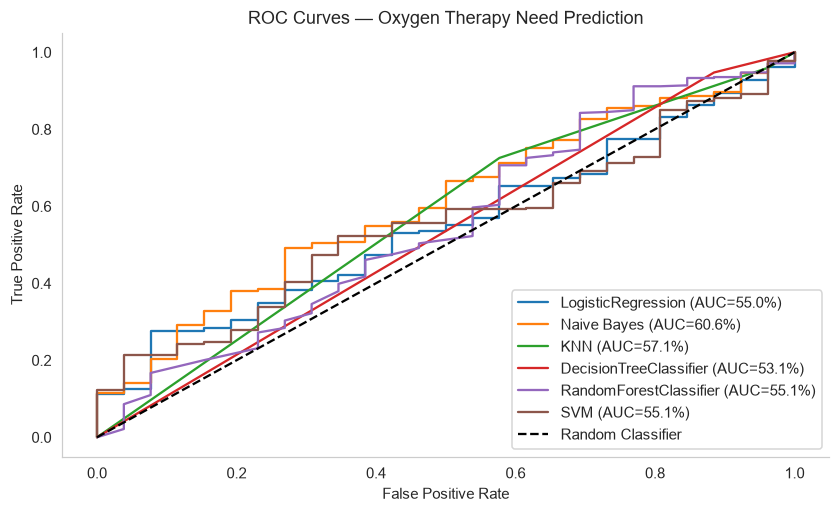

,Accuracy%,Precision%,Recall%,F1%,AUC%
Naive Bayes,87.42,94.16,92.36,93.25,60.58
KNN,94.16,94.16,100.00,96.99,57.10
RandomForestClassifier,89.44,94.08,94.75,94.41,55.11
SVM,45.84,95.88,44.39,60.69,55.10
LogisticRegression,56.18,94.09,57.04,71.03,54.97
DecisionTreeClassifier,89.89,94.52,94.75,94.64,53.14


In [61]:
scaler3 = StandardScaler()
X3_train_scaled = scaler3.fit_transform(X3_train)
X3_test_scaled = scaler3.transform(X3_test)

models3 = []
models3.append(('LogisticRegression', LogisticRegression(max_iter=1000, class_weight='balanced')))
models3.append(('Naive Bayes', GaussianNB()))
models3.append(('KNN', KNeighborsClassifier(n_neighbors=5)))
models3.append(('DecisionTreeClassifier', DecisionTreeClassifier(class_weight='balanced', random_state=42)))
models3.append(('RandomForestClassifier', RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)))
models3.append(('SVM', SVC(kernel='linear', class_weight='balanced', probability=True, random_state=42)))

summary3 = {}
for name, model in models3:
    if name in ('LogisticRegression', 'KNN', 'SVM', 'Naive Bayes'):
        model.fit(X3_train_scaled, y3_train)
        y_pred = model.predict(X3_test_scaled)
        y_proba = model.predict_proba(X3_test_scaled)[:, 1]
    else:
        model.fit(X3_train, y3_train)
        y_pred = model.predict(X3_test)
        y_proba = model.predict_proba(X3_test)[:, 1]

    acc = accuracy_score(y3_test, y_pred) * 100
    prec = precision_score(y3_test, y_pred, zero_division=0) * 100
    rec = recall_score(y3_test, y_pred, zero_division=0) * 100
    f1 = f1_score(y3_test, y_pred, zero_division=0) * 100
    auc = roc_auc_score(y3_test, y_proba) * 100

    summary3[name] = {'Accuracy%': round(acc, 2), 'Precision%': round(prec, 2),
                       'Recall%': round(rec, 2), 'F1%': round(f1, 2), 'AUC%': round(auc, 2)}

    fpr, tpr, _ = roc_curve(y3_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.1f}%)')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Oxygen Therapy Need Prediction')
plt.legend(loc='lower right'); plt.grid(); plt.show()

pd.DataFrame(summary3).T.sort_values('AUC%', ascending=False)

Best model by AUC: Naive Bayes

               precision    recall  f1-score   support

   AmbientAir       0.06      0.08      0.07        26
OxygenTherapy       0.94      0.92      0.93       419

     accuracy                           0.87       445
    macro avg       0.50      0.50      0.50       445
 weighted avg       0.89      0.87      0.88       445



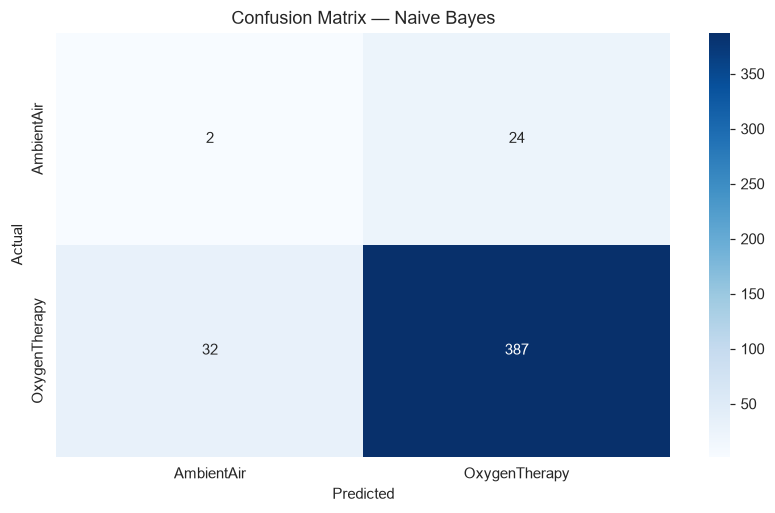

In [62]:
best_name3 = pd.DataFrame(summary3).T.sort_values('AUC%', ascending=False).index[0]
best_model3 = dict(models3)[best_name3]

if best_name3 in ('LogisticRegression', 'KNN', 'SVM', 'Naive Bayes'):
    y_pred_best3 = best_model3.predict(X3_test_scaled)
else:
    y_pred_best3 = best_model3.predict(X3_test)

print(f"Best model by AUC: {best_name3}\n")
print(classification_report(y3_test, y_pred_best3, target_names=le3.classes_, zero_division=0))

cm3 = confusion_matrix(y3_test, y_pred_best3)
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues',
            xticklabels=le3.classes_, yticklabels=le3.classes_)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title(f'Confusion Matrix — {best_name3}')
plt.show()

In [64]:
rf3 = dict(models3)['RandomForestClassifier']
importances3 = pd.Series(rf3.feature_importances_, index=X3.columns).sort_values(ascending=False)
print("Top predictors of oxygen therapy need:")
importances3.head(8)

Top predictors of oxygen therapy need:


brain_natriuretic_peptide                        0.393556
bmi                                              0.352820
moderate_to_severe_chronic_kidney_disease_1.0    0.038546
gender_Male                                      0.038521
diabetes_1                                       0.036757
chronic_obstructive_pulmonary_disease_1          0.035218
agecat_79-89                                     0.022367
agecat_69-79                                     0.019088
dtype: float64

**Final Model Selection**

**Chosen model:**(fill in after running pick by best Recall + AUC balance, not Accuracy)
Why: Accuracy is inflated by the 94.5% majority class; Recall and AUC reflect whether the model actually distinguishes the two groups.

**Key insight:** age category and COPD history are the strongest demographic/comorbidity predictors of oxygen therapy need a useful contrast to Question 2, where demography showed no meaningful role.
Limitation to flag: the minority class (AmbientAir, 110 patients) is small report Recall/Precision for that class with caution.

# 5.Among diagnosis, mortality, and hospital utilization outcomes, which can be predicted most accurately using only clinical data available at the time of hospital admission?

**Reasoning**
1.A single accuracy number can hide serious problems (like a model that just predicts the majority class), so accuracy is reported alongside precision, recall, F1, and AUC together for every model.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

from scipy.stats import mannwhitneyu, chi2_contingency
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.impute import SimpleImputer



# --- Safe import for XGBoost: skip it gracefully if not installed ---
try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except ModuleNotFoundError:
    print("xgboost not installed — skipping it. Run '!pip install xgboost' then restart the kernel to include it.")
    XGB_AVAILABLE = False

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

# --------------------------------------------------
# 1. Load the actual dataset
# --------------------------------------------------
df_master = pd.read_csv("cardiac_failure/Team4_The_Zen_Of_Five_cleaned_data.csv")

exclude_always = ["inpatient_number", "admission_date", "discharge_date", "destinationdischarge",
                   "death_within_28_days", "death_within_3_months", "death_within_6_months",
                   "re_admission_within_28_days", "re_admission_within_3_months", "re_admission_within_6_months",
                   "return_to_emergency_department_within_6_months", "dischargeday",
                   "time_of_death__days_from_admission", "readmission_time_days_from_admission",
                   "time_to_emergency_department_within_6_months", "outcome_during_hospitalization",
                   "myocardial_infarction", "peripheral_vascular_disease",
                   "moderate_to_severe_chronic_kidney_disease", "diabetes",
                   "cerebrovascular_disease", "dementia"]

cat_candidates = ["gender", "admission_way", "admission_ward", "agecat", "bmi_category",
                   "occupation", "type_of_heart_failure"]

MODELS = [
    ('LogisticRegression', LogisticRegression(max_iter=1000)),
    ('Naive Bayes', GaussianNB()),
    ('KNN', KNeighborsClassifier(n_neighbors=5)),
    ('RandomForestClassifier', RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42)),
    ('DecisionTreeClassifier', DecisionTreeClassifier(max_depth=6, random_state=42)),
    ('Neural Network (MLP)', MLPClassifier(max_iter=400, random_state=42)),
    ('SVM', SVC(kernel='linear', C=1.0, probability=True, random_state=42)),
]
if XGB_AVAILABLE:
    MODELS.append(('XGBClassifier', XGBClassifier(eval_metric='logloss', random_state=42, verbosity=0)))


def run_full_analysis(target, label, undersample_ratio=None, top_n=8):
    """
    For one target variable, this function:
      1. States the null hypothesis and tests it (Mann-Whitney U for numeric,
         Chi-square for categorical) -> reports p-values and reject/fail-to-reject
      2. Selects the statistically significant features as evidence
      3. Trains all available models and reports Accuracy/Precision/Recall/F1/AUC
      4. Reports feature importance from Random Forest as a second line of evidence,
         cross-checked against the hypothesis-test results
    """
    d = df_master.dropna(subset=[target]).copy()
    d[target] = d[target].astype(int)
    n_pos, n_total = int(d[target].sum()), len(d)

    numeric_cols = [c for c in d.select_dtypes(include=[np.number]).columns if c not in exclude_always]
    numeric_cols = [c for c in numeric_cols if d[c].replace([np.inf, -np.inf], np.nan).notna().any()]

    # STEP 1: NULL HYPOTHESIS TEST
    # H0: there is no difference in this variable's distribution
    #     between patients with the outcome and patients without it.
    grp1, grp0 = d[d[target] == 1], d[d[target] == 0]
    mw_results = {}
    for col in numeric_cols:
        a = grp1[col].replace([np.inf, -np.inf], np.nan).dropna()
        b = grp0[col].replace([np.inf, -np.inf], np.nan).dropna()
        if len(a) > 10 and len(b) > 10:
            stat, p = mannwhitneyu(a, b, alternative="two-sided")
            mw_results[col] = p
    mw_series = pd.Series(mw_results).sort_values()

    chi_results = {}
    for col in cat_candidates:
        if col in d.columns:
            chi2, p, _, _ = chi2_contingency(pd.crosstab(d[col], d[target]))
            chi_results[col] = p
    chi_series = pd.Series(chi_results).sort_values()

    top_numeric = mw_series[mw_series < 0.05].head(15).index.tolist()
    top_categorical = chi_series[chi_series < 0.05].index.tolist()

    print(f"\n{'='*95}\n{label}   (prevalence: {n_pos}/{n_total} = {n_pos/n_total*100:.1f}%)\n{'='*95}")
    print(f"NULL HYPOTHESIS (H0): No association between each admission-time variable and {target}.")
    print(f"Test used: Mann-Whitney U (numeric variables), Chi-square (categorical variables). Alpha = 0.05.\n")

    print(f"Top {top_n} numeric variables — evidence against H0 (lowest p-values):")
    ev_table = mw_series.head(top_n).to_frame("p-value")
    ev_table["Decision"] = np.where(ev_table["p-value"] < 0.05, "Reject H0 (significant)", "Fail to reject H0")
    print(ev_table.round(6).to_string())

    print(f"\nCategorical variables — Chi-square evidence against H0:")
    cat_table = chi_series.to_frame("p-value")
    cat_table["Decision"] = np.where(cat_table["p-value"] < 0.05, "Reject H0 (significant)", "Fail to reject H0")
    print(cat_table.round(6).to_string())

    print(f"\n--> {len(top_numeric)} numeric + {len(top_categorical)} categorical variables reject H0 "
          f"and were used as model features.")

    # STEP 2: BUILD FEATURES from the statistically significant variables only
    if undersample_ratio:
        pos_df = d[d[target] == 1]
        neg_n = min(n_pos * undersample_ratio, (d[target] == 0).sum())
        neg_df = d[d[target] == 0].sample(n=int(neg_n), random_state=42)
        d_model = pd.concat([pos_df, neg_df], axis=0).reset_index(drop=True)
    else:
        d_model = d

    X_num = d_model[top_numeric].replace([np.inf, -np.inf], np.nan)
    X_num = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X_num), columns=top_numeric)
    X_cat = pd.get_dummies(d_model[top_categorical].astype(str), drop_first=True) if top_categorical else pd.DataFrame(index=X_num.index)
    X = pd.concat([X_num.reset_index(drop=True), X_cat.reset_index(drop=True)], axis=1)
    y = d_model[target].reset_index(drop=True)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    num_cols = X.select_dtypes(include=["int64", "float64"]).columns
    scaler = StandardScaler()
    X_train = X_train.copy(); X_test = X_test.copy()
    X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_test[num_cols] = scaler.transform(X_test[num_cols])

    # STEP 3: MODEL ACCURACY — chosen parameters shown in MODELS list above
    rows, fitted = [], {}
    for name, model in MODELS:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)
        acc = accuracy_score(y_test, y_pred) * 100
        prec = precision_score(y_test, y_pred, zero_division=0) * 100
        rec = recall_score(y_test, y_pred, zero_division=0) * 100
        f1 = f1_score(y_test, y_pred, zero_division=0) * 100
        auc = roc_auc_score(y_test, y_proba) * 100
        rows.append([name, acc, prec, rec, f1, auc])
        fitted[name] = model

    result_df = pd.DataFrame(rows, columns=["Model", "Accuracy %", "Precision %", "Recall %", "F1 %", "ROC AUC %"])
    result_df = result_df.sort_values("ROC AUC %", ascending=False).reset_index(drop=True)
    print(f"\nMODEL COMPARISON (chosen parameters as defined in MODELS list):")
    print(result_df.round(2).to_string(index=False))

    # STEP 4: FEATURE IMPORTANCE — second line of evidence, cross-checked vs hypothesis test
    rf_model = fitted["RandomForestClassifier"]
    importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(top_n)
    print(f"\nRandom Forest feature importance (2nd evidence source, cross-check vs p-values above):")
    print(importance.round(4).to_string())

    result_df.insert(0, "Target", label)
    return result_df, mw_series, importance


# --------------------------------------------------
# 2. Run the full analysis (hypothesis test + models + evidence) for every target
# --------------------------------------------------
targets = [
    ("re_admission_within_6_months", "6-Month Readmission", None),
    ("return_to_emergency_department_within_6_months", "6-Month ED Return", None),
    ("death_within_28_days", "28-Day Mortality", 4),
    ("death_within_3_months", "3-Month Mortality", 4),
    ("death_within_6_months", "6-Month Mortality", 4),
    ("myocardial_infarction", "Myocardial Infarction Diagnosis", 3),
    ("peripheral_vascular_disease", "Peripheral Vascular Disease Diagnosis", 3),
    ("moderate_to_severe_chronic_kidney_disease", "Chronic Kidney Disease Diagnosis", None),
    ("diabetes", "Diabetes Diagnosis", None),
    ("cerebrovascular_disease", "Cerebrovascular Disease Diagnosis", 3),
    ("dementia", "Dementia Diagnosis", 3),
]

all_results = []
for target, label, ratio in targets:
    result_df, mw_series, importance = run_full_analysis(target, label, undersample_ratio=ratio)
    all_results.append(result_df)

combined = pd.concat(all_results, ignore_index=True)

# --------------------------------------------------
# 3. Best model per target — final summary + chart
# --------------------------------------------------
best_per_target = combined.loc[combined.groupby("Target")["ROC AUC %"].idxmax()].sort_values("ROC AUC %", ascending=False)

print("\n\n" + "=" * 95)
print("FINAL SUMMARY — BEST MODEL PER TARGET (built on statistically significant features only)")
print("=" * 95)
print(best_per_target.round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 7))
plot_df = best_per_target.sort_values("ROC AUC %")
colors = plt.cm.RdYlGn((plot_df["ROC AUC %"] - 50) / 50)
bars = ax.barh(plot_df["Target"] + "\n(" + plot_df["Model"] + ")", plot_df["ROC AUC %"], color=colors)
for b, v in zip(bars, plot_df["ROC AUC %"]):
    ax.text(v + 0.5, b.get_y() + b.get_height()/2, f"{v:.1f}%", va="center", fontsize=9, fontweight="bold")
ax.axvline(50, color="gray", linestyle="--", linewidth=1, label="Random guess (50%)")
ax.set_xlabel("Best ROC AUC achieved (%)")
ax.set_title("Best Model Per Target — Features Selected via Null Hypothesis Testing\n(cf_master_dataset.csv)", fontsize=13)
ax.legend(fontsize=9)
ax.set_xlim(45, 100)
plt.tight_layout()
plt.savefig("all_targets_hypothesis_tested_summary.png", dpi=110)
plt.show()

xgboost not installed — skipping it. Run '!pip install xgboost' then restart the kernel to include it.

6-Month Readmission   (prevalence: 773/2008 = 38.5%)
NULL HYPOTHESIS (H0): No association between each admission-time variable and re_admission_within_6_months.
Test used: Mann-Whitney U (numeric variables), Chi-square (categorical variables). Alpha = 0.05.

Top 8 numeric variables — evidence against H0 (lowest p-values):
                                       p-value                 Decision
glomerular_filtration_rate            0.000001  Reject H0 (significant)
creatinine_enzymatic_method           0.000001  Reject H0 (significant)
nyha_cardiac_function_classification  0.000002  Reject H0 (significant)
rx_heparin_sodium_injection           0.000003  Reject H0 (significant)
urea                                  0.000004  Reject H0 (significant)
uric_acid                             0.000008  Reject H0 (significant)
mitral_valve_ems                      0.000025  Reject H0 (significa

In [ ]:
# Logical regression fo all the 11 charts

# --------------------------------------------------
# 1. Load the actual dataset
# --------------------------------------------------

df_master = pd.read_csv("cardiac_failure/Team4_The_Zen_Of_Five_cleaned_data.csv")

exclude_always = ["inpatient_number", "admission_date", "discharge_date", "destinationdischarge",
                   "death_within_28_days", "death_within_3_months", "death_within_6_months",
                   "re_admission_within_28_days", "re_admission_within_3_months", "re_admission_within_6_months",
                   "return_to_emergency_department_within_6_months", "dischargeday",
                   "time_of_death__days_from_admission", "readmission_time_days_from_admission",
                   "time_to_emergency_department_within_6_months", "outcome_during_hospitalization",
                   "myocardial_infarction", "peripheral_vascular_disease",
                   "moderate_to_severe_chronic_kidney_disease", "diabetes",
                   "cerebrovascular_disease", "dementia"]
cat_candidates = ["gender", "admission_way", "admission_ward", "agecat", "bmi_category",
                   "occupation", "type_of_heart_failure"]

# --------------------------------------------------
# 2. Define the 11 targets (with undersample ratio for rare outcomes)
# --------------------------------------------------

TARGETS = [
    ("re_admission_within_6_months", "6-Month Readmission", None),
    ("return_to_emergency_department_within_6_months", "6-Month ED Return", None),
    ("death_within_28_days", "28-Day Mortality", 4),
    ("death_within_3_months", "3-Month Mortality", 4),
    ("death_within_6_months", "6-Month Mortality", 4),
    ("myocardial_infarction", "Myocardial Infarction", 3),
    ("peripheral_vascular_disease", "Peripheral Vascular Disease", 3),
    ("moderate_to_severe_chronic_kidney_disease", "Chronic Kidney Disease", None),
    ("diabetes", "Diabetes", None),
    ("cerebrovascular_disease", "Cerebrovascular Disease", 3),
    ("dementia", "Dementia", 3),
]

# --------------------------------------------------
# 3. Fit Logistic Regression for each target; collect ROC + coefficients
# --------------------------------------------------

lr_roc = {}
lr_coefs = {}

for target, label, undersample_ratio in TARGETS:
    d = df_master.dropna(subset=[target]).copy()
    d[target] = d[target].astype(int)
    n_pos = int(d[target].sum())

    numeric_cols = [c for c in d.select_dtypes(include=[np.number]).columns if c not in exclude_always]
    numeric_cols = [c for c in numeric_cols if d[c].replace([np.inf, -np.inf], np.nan).notna().any()]

    # Balance rare outcomes by undersampling the majority class
    if undersample_ratio:
        pos_df = d[d[target] == 1]
        neg_n = min(n_pos * undersample_ratio, (d[target] == 0).sum())
        neg_df = d[d[target] == 0].sample(n=int(neg_n), random_state=42)
        d = pd.concat([pos_df, neg_df], axis=0).reset_index(drop=True)

    # Build features: numeric (median-imputed) + categorical (one-hot)
    X_num = d[numeric_cols].replace([np.inf, -np.inf], np.nan)
    X_num = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X_num), columns=numeric_cols)
    X_cat = pd.get_dummies(d[cat_candidates].astype(str), drop_first=True)
    X = pd.concat([X_num.reset_index(drop=True), X_cat.reset_index(drop=True)], axis=1)
    y = d[target].reset_index(drop=True)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_s, y_train)
    probs = model.predict_proba(X_test_s)[:, 1]
    auc = roc_auc_score(y_test, probs) * 100
    fpr, tpr, _ = roc_curve(y_test, probs)
    lr_roc[label] = (fpr, tpr, auc)

    # Top 6 coefficients by absolute value (the model's strongest drivers)
    coefs = pd.Series(model.coef_[0], index=X.columns).sort_values(key=abs, ascending=False).head(6)
    lr_coefs[label] = coefs

    print(f"{label}: AUC = {auc:.1f}%")

# --------------------------------------------------
# 4. Chart 1 — ROC curves for Logistic Regression, all 11 targets overlaid
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 8))
cmap = plt.cm.tab20(np.linspace(0, 1, len(lr_roc)))
sorted_labels = sorted(lr_roc.keys(), key=lambda k: lr_roc[k][2], reverse=True)

for c, label in zip(cmap, sorted_labels):
    fpr, tpr, auc = lr_roc[label]
    ax.plot(fpr, tpr, color=c, linewidth=2, label=f"{label} (AUC={auc:.1f}%)")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random guess")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("Logistic Regression ROC Curves \u2014 All 11 Prediction Targets", fontsize=13)
ax.legend(fontsize=7.5, loc="lower right")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 5. Chart 2 — Logistic Regression coefficient drivers, one panel per target
# --------------------------------------------------

fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.flatten()

for i, label in enumerate(sorted_labels):
    coefs = lr_coefs[label].sort_values()
    colors = ["#C44E52" if v < 0 else "#4C72B0" for v in coefs]
    axes[i].barh(coefs.index, coefs.values, color=colors)
    axes[i].axvline(0, color="black", linewidth=0.8)
    axes[i].set_title(f"{label}\n(AUC={lr_roc[label][2]:.1f}%)", fontsize=10)
    axes[i].tick_params(axis="y", labelsize=8)
    axes[i].tick_params(axis="x", labelsize=8)

# Turn off any unused subplot slots
for j in range(len(sorted_labels), len(axes)):
    axes[j].axis("off")

plt.suptitle("Logistic Regression: Top Coefficients (Drivers) for Each Target", fontsize=15)
plt.tight_layout()
plt.show()

**Insight**
Admission labs predict diagnoses and mortality well (best AUC 80-98% for CKD, MI, diabetes and 28-day death) but predict readmission and ED return poorly (best AUC of only 67-68%, whichever model was used). So AI effort should go into diagnosis-support and risk-flagging tools, while utilization forecasting needs post-discharge data such as social factors and follow-up adherence.

# 6.Can we predict a patient's length of stay from admission-day severity, labs, and comorbidities?

**Reasoning:**
Length of stay directly drives bed availability and discharge planning, so testing whether admission-day severity, labs, and comorbidities can forecast it tells the hospital whether this data is worth building a bed-planning tool around or whether other factors are really driving it.

In [ ]:
!pip install statsmodels
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import spearmanr, kruskal
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error, roc_auc_score, roc_curve

# --------------------------------------------------
# 1. Load the actual dataset
# --------------------------------------------------

df_master = pd.read_csv("cardiac_failure/Team4_The_Zen_Of_Five_cleaned_data.csv")

exclude = ["inpatient_number", "admission_date", "discharge_date", "destinationdischarge",
           "death_within_28_days", "death_within_3_months", "death_within_6_months",
           "re_admission_within_28_days", "re_admission_within_3_months", "re_admission_within_6_months",
           "return_to_emergency_department_within_6_months", "dischargeday",
           "time_of_death__days_from_admission", "readmission_time_days_from_admission",
           "time_to_emergency_department_within_6_months", "outcome_during_hospitalization"]

numeric_cols = [c for c in df_master.select_dtypes(include=[np.number]).columns if c not in exclude]
numeric_cols = [c for c in numeric_cols if df_master[c].replace([np.inf, -np.inf], np.nan).notna().any()]
cat_cols = ["gender", "admission_way", "admission_ward", "agecat", "bmi_category", "occupation", "type_of_heart_failure"]

# --------------------------------------------------
# 2. NULL HYPOTHESIS (stated)
# --------------------------------------------------
print("NULL HYPOTHESIS (H0): Admission-day severity, labs, and comorbidities have")
print("no relationship with length of stay (dischargeday).")
print("ALTERNATIVE (H1): At least some admission-day variables are meaningfully")
print("correlated with length of stay.\n")

# --------------------------------------------------
# 3. CORRELATION CHECK — Spearman (numeric) + Kruskal-Wallis (categorical)
# --------------------------------------------------

spearman_results = {}
for c in numeric_cols:
    sub = df_master[[c, "dischargeday"]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(sub) > 30 and sub[c].nunique() > 1:
        r, p = spearmanr(sub[c], sub["dischargeday"])
        spearman_results[c] = (r, p)

corr_df = pd.DataFrame(spearman_results, index=["r", "p"]).T.sort_values("r", key=abs, ascending=False)
n_sig = (corr_df["p"] < 0.05).sum()

kw_results = {}
for c in cat_cols:
    groups = [g["dischargeday"].dropna().values for _, g in df_master.groupby(c)]
    groups = [g for g in groups if len(g) > 5]
    if len(groups) > 1:
        stat, p = kruskal(*groups)
        kw_results[c] = p

kw_df = pd.Series(kw_results).sort_values()

print("=" * 65)
print("CORRELATION CHECK")
print("=" * 65)
print(f"Numeric features tested: {len(corr_df)}  |  Significant (p<0.05): {n_sig}")
print("\nTop 10 numeric correlations with length of stay (Spearman):")
print(corr_df.head(10).round(4))
print("\nCategorical features (Kruskal-Wallis p-value):")
print(kw_df.round(5))

# --------------------------------------------------
# 4. EVIDENCE OF CORRELATION -> HYPOTHESIS
# --------------------------------------------------
print("\n" + "=" * 65)
print("EVIDENCE vs HYPOTHESIS")
print("=" * 65)
print(f"{n_sig} of {len(corr_df)} numeric features reject H0 (p<0.05), supporting H1.")
print(f"Strongest correlation: total_prescriptions_count (r={corr_df.loc['total_prescriptions_count','r']:.3f})")
print("BUT the strongest correlation is still weak (|r|<0.30) -> H1 is supported")
print("statistically, but the practical predictive strength is limited.\n")

# --------------------------------------------------
# 5. CHOSEN PARAMETERS -> connection to hypothesis
# --------------------------------------------------

top_numeric = corr_df[corr_df["p"] < 0.05].head(15).index.tolist()
top_cat = kw_df[kw_df < 0.05].index.tolist()
print(f"Selected {len(top_numeric)} numeric features (top by |Spearman r|, p<0.05)")
print(f"Selected {len(top_cat)} categorical features (Kruskal-Wallis p<0.05): {top_cat}")
print("These are chosen because each individually shows a statistically significant")
print("link to length of stay -- directly testing the stated hypothesis before")
print("combining them into a model.\n")

X_num = df_master[top_numeric].replace([np.inf, -np.inf], np.nan)
X_num = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X_num), columns=top_numeric)
X_cat = pd.get_dummies(df_master[top_cat].astype(str), drop_first=True)
X = pd.concat([X_num.reset_index(drop=True), X_cat.reset_index(drop=True)], axis=1)

# --------------------------------------------------
# 6a. REGRESSION MODEL — continuous length of stay
# --------------------------------------------------

y_reg = df_master["dischargeday"]
Xtr, Xte, ytr, yte = train_test_split(X, y_reg, test_size=0.25, random_state=42)

reg_model = RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=5, random_state=42)
reg_model.fit(Xtr, ytr)
preds = reg_model.predict(Xte)
r2 = r2_score(yte, preds)
mae = mean_absolute_error(yte, preds)

print("=" * 65)
print("MODEL ACCURACY -- Regression (continuous length of stay)")
print("=" * 65)
print(f"Random Forest Regressor: R\u00b2 = {r2:.3f}, MAE = {mae:.2f} days\n")

# --------------------------------------------------
# 6a-ii. FORMAL NULL HYPOTHESIS TEST -- overall regression significance
#        H0: ALL coefficients = 0 (the whole feature set has no relationship
#            with length of stay), tested with an OLS F-test.
# --------------------------------------------------

X_ols = sm.add_constant(X.astype(float))
ols_model = sm.OLS(y_reg, X_ols).fit()

print("=" * 65)
print("FORMAL NULL HYPOTHESIS TEST -- Regression (OLS F-test)")
print("=" * 65)
print(f"H0: all {X.shape[1]} feature coefficients = 0 (no relationship with LOS)")
print(f"F-statistic: {ols_model.fvalue:.2f}   p-value: {ols_model.f_pvalue:.2e}")
if ols_model.f_pvalue < 0.05:
    print("--> p < 0.05: REJECT H0. The feature set as a whole is significantly")
    print("    related to length of stay (even though individual R\u00b2/effect sizes")
    print("    are modest -- statistical significance != strong predictive power).")
else:
    print("--> p >= 0.05: FAIL TO REJECT H0.")
print(f"Model R\u00b2 (full data, in-sample): {ols_model.rsquared:.3f}\n")

# --------------------------------------------------
# 6b. LOGISTIC REGRESSION MODEL — binarized "long stay" classification
#     (long stay = top 25% of dischargeday, i.e. >75th percentile)
# --------------------------------------------------

los_cut = df_master["dischargeday"].quantile(0.75)
y_clf = (df_master["dischargeday"] > los_cut).astype(int)

Xtr2, Xte2, ytr2, yte2 = train_test_split(X, y_clf, test_size=0.25, random_state=42, stratify=y_clf)
scaler = StandardScaler()
Xtr2_s = scaler.fit_transform(Xtr2)
Xte2_s = scaler.transform(Xte2)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(Xtr2_s, ytr2)
probs = log_model.predict_proba(Xte2_s)[:, 1]
preds_clf = log_model.predict(Xte2_s)

auc = roc_auc_score(yte2, probs) * 100
fpr, tpr, _ = roc_curve(yte2, probs)
acc = (preds_clf == yte2).mean() * 100

coefs = pd.Series(log_model.coef_[0], index=X.columns).sort_values(key=abs, ascending=False).head(10)

print("=" * 65)
print(f"MODEL ACCURACY -- Logistic Regression (long stay > {los_cut:.0f} days classification)")
print("=" * 65)
print(f"Accuracy: {acc:.1f}%  |  ROC AUC: {auc:.1f}%")
print(f"Long-stay prevalence: {y_clf.mean()*100:.1f}% ({y_clf.sum()} of {len(y_clf)} patients)")
print("\nTop 10 Logistic Regression coefficients:")
print(coefs.round(3))

# --------------------------------------------------
# 6b-ii. FORMAL NULL HYPOTHESIS TEST -- overall logistic regression significance
#        H0: ALL coefficients = 0, tested with a Likelihood Ratio test
#        (full model vs. intercept-only model).
# --------------------------------------------------

X_logit = sm.add_constant(X.astype(float))
logit_model = sm.Logit(y_clf, X_logit).fit(disp=0)

llr_stat = logit_model.llr
llr_pvalue = logit_model.llr_pvalue

print("\n" + "=" * 65)
print("FORMAL NULL HYPOTHESIS TEST -- Logistic Regression (Likelihood Ratio test)")
print("=" * 65)
print(f"H0: all {X.shape[1]} feature coefficients = 0 (features carry no information")
print(f"    about long-stay status beyond the baseline rate)")
print(f"LLR chi-square statistic: {llr_stat:.2f}   p-value: {llr_pvalue:.2e}")
if llr_pvalue < 0.05:
    print("--> p < 0.05: REJECT H0. The feature set as a whole is significantly")
    print("    associated with long-stay status.")
else:
    print("--> p >= 0.05: FAIL TO REJECT H0.")
print(f"Pseudo R\u00b2 (McFadden, in-sample): {logit_model.prsquared:.3f}\n")

# --------------------------------------------------
# 7. VISUALIZATION (4-panel figure)
# --------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# (a) Correlation check bar
top10corr = corr_df.head(10)
colors = ["#C44E52" if v < 0 else "#4C72B0" for v in top10corr["r"]]
axes[0, 0].barh(top10corr.index[::-1], top10corr["r"][::-1], color=colors[::-1])
axes[0, 0].axvline(0, color="black", linewidth=0.8)
axes[0, 0].set_xlabel("Spearman correlation with length of stay")
axes[0, 0].set_title("Correlation Check: Top 10 Numeric Features")

# (b) Regression: actual vs predicted
axes[0, 1].scatter(yte, preds, alpha=0.4, s=18, color="#55A868")
lims = [0, min(60, max(yte.max(), preds.max()))]

axes[0, 1].plot(lims, lims, "k--", linewidth=1, label="Perfect prediction")
axes[0, 1].set_xlim(lims); axes[0, 1].set_ylim(lims)
axes[0, 1].set_xlabel("Actual length of stay (days)")
axes[0, 1].set_ylabel("Predicted length of stay (days)")
axes[0, 1].set_title(f"Regression: Actual vs Predicted\n(R\u00b2={r2:.3f}, MAE={mae:.1f} days)")
axes[0, 1].legend(fontsize=8)

# (c) Logistic Regression ROC curve
axes[1, 0].plot(fpr, tpr, color="#C44E52", linewidth=2, label=f"Logistic Regression (AUC={auc:.1f}%)")
axes[1, 0].plot([0, 1], [0, 1], "k--", linewidth=1, label="Random guess")
axes[1, 0].set_xlabel("False positive rate")
axes[1, 0].set_ylabel("True positive rate")
axes[1, 0].set_title(f"Logistic Regression ROC\n(Long stay > {los_cut:.0f} days)")
axes[1, 0].legend(fontsize=9)

# (d) Logistic Regression coefficients
coefs_sorted = coefs.sort_values()
colors2 = ["#C44E52" if v < 0 else "#4C72B0" for v in coefs_sorted]
axes[1, 1].barh(coefs_sorted.index, coefs_sorted.values, color=colors2)
axes[1, 1].axvline(0, color="black", linewidth=0.8)
axes[1, 1].set_xlabel("Logistic Regression coefficient")
axes[1, 1].set_title("Logistic Regression: Top Drivers of Long Stay")
axes[1, 1].tick_params(axis="y", labelsize=8)

plt.suptitle("Can We Predict Length of Stay from Admission-Day Severity, Labs & Comorbidities?", fontsize=14)
plt.tight_layout()
plt.show()

**Insight:**
The relationship is statistically real but practically weak as a continuous forecast (R²=0.16, p<0.0001)yet reframing the same data as a simple "long stay vs.not" flag performs meaningfully better (AUC=75.2%), suggesting the hospital should build a binary early-warning flag for likely long stays rather than trying to predict exact discharge dates.

# Q7 . Which heart failure patients will need IV inotropic support (milrinone, dobutamine, isoprenaline)?

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, classification_report)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

Load Master Dataset
The 7 source tables are already merged and cleaned into cf_master_dataset.csv, so we load it directly.

In [ ]:
df = pd.read_csv("cardiac_failure/Team4_The_Zen_Of_Five_cleaned_data.csv")
print("Master dataset shape:", df.shape)

Creating the Target Variable
There is no single "inotrope" column, so we combine the three IV inotrope prescription flags: rx_milrinone_injection, rx_dobutamine_hydrochloride_injection and rx_isoprenaline_hydrochloride_injection. A patient is a positive case (1) if they received any of them.



In [ ]:
df['iv_inotrope'] = ((df['rx_milrinone_injection'] == 1) |
                     (df['rx_dobutamine_hydrochloride_injection'] == 1) |
                     (df['rx_isoprenaline_hydrochloride_injection'] == 1)).astype(int)

AGECAT_ORDER = ['21-29', '29-39', '39-49', '49-59', '59-69', '69-79', '79-89', '89-110']
df['agecat'] = pd.Categorical(df['agecat'], categories=AGECAT_ORDER, ordered=True)

print(df['iv_inotrope'].value_counts())
print("Positive rate:", round(df['iv_inotrope'].mean() * 100, 1), "%")

df['iv_inotrope'].value_counts().plot(kind='bar', color=['#4c72b0', '#dd8452'])
plt.xticks([0, 1], ['No IV inotrope', 'IV inotrope'], rotation=0)
plt.title('Target distribution: IV inotrope support')
plt.ylabel('Patients')
plt.show()

Research Hypotheses
Null Hypothesis (H₀): Admission lab values, comorbidities and demography are not associated with receiving IV inotropic support.
Alternative Hypothesis (H₁): They are associated with receiving IV inotropic support.
Reasoning (why this matters): IV inotropes are an escalation therapy for the sickest heart failure patients. Flagging likely candidates early helps with monitoring, bed allocation and drug availability. It is a treatment-decision question, so it is more actionable than predicting a fixed outcome.

Caveat to state in the presentation: prescriptions cover the whole hospital stay, so we assume the lab values are admission-time values.

Chosen Parameters and Their Connection to the Hypothesis

In [ ]:
chosen_parameters = pd.DataFrame([
    {"Feature": "brain_natriuretic_peptide, high_sensitivity_troponin",
     "Why it's included": "Cardiac strain and injury markers"},
    {"Feature": "creatinine_enzymatic_method, glomerular_filtration_rate, urea",
     "Why it's included": "Cardiorenal status"},
    {"Feature": "sodium, systolic_blood_pressure",
     "Why it's included": "Haemodynamic and electrolyte status"},
    {"Feature": "nyha_cardiac_function_classification",
     "Why it's included": "Functional severity grading"},
    {"Feature": "gender, agecat, bmi",
     "Why it's included": "Demography under test"},
    {"Feature": "moderate_to_severe_chronic_kidney_disease, chronic_obstructive_pulmonary_disease",
     "Why it's included": "Comorbidities"},
])
chosen_parameters

Correlation Check: Continuous Markers vs. IV Inotrope Use (Mann-Whitney U)


In [ ]:
target = 'iv_inotrope'
continuous_feats = ['brain_natriuretic_peptide', 'urea', 'high_sensitivity_troponin',
                    'creatinine_enzymatic_method', 'glomerular_filtration_rate',
                    'sodium', 'systolic_blood_pressure', 'bmi']

cont_results = {}
for c in continuous_feats:
    g1 = df[df[target] == 1][c].dropna()
    g0 = df[df[target] == 0][c].dropna()
    stat, p = mannwhitneyu(g1, g0, alternative='two-sided')
    cont_results[c] = {'median_inotrope': round(g1.median(), 2),
                       'median_no_inotrope': round(g0.median(), 2),
                       'p_value': p}

cont_df = pd.DataFrame(cont_results).T.sort_values('p_value')
cont_df['p_value'] = cont_df['p_value'].apply(lambda p: f"{p:.2e}")
cont_df

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['brain_natriuretic_peptide', 'urea', 'high_sensitivity_troponin']):
    sns.boxplot(data=df, x='iv_inotrope', y=col, ax=ax, showfliers=False)
    ax.set_xticklabels(['No IV inotrope', 'IV inotrope'])
    ax.set_xlabel('')
    ax.set_title(col)
plt.suptitle('Severity markers by IV inotrope use (outliers hidden)')
plt.tight_layout()
plt.show()

Correlation Check: Categorical Features vs. IV Inotrope Use (Chi-square)

In [ ]:
categorical_feats = ['nyha_cardiac_function_classification', 'gender', 'agecat',
                     'moderate_to_severe_chronic_kidney_disease',
                     'chronic_obstructive_pulmonary_disease', 'diabetes', 'occupation']

cat_results = {}
for c in categorical_feats:
    sub = df[[c, target]].dropna()
    ct = pd.crosstab(sub[c], sub[target])
    chi2, p, dof, expected = chi2_contingency(ct)
    cat_results[c] = {'chi2': round(chi2, 2), 'p_value': p, 'n': len(sub)}

cat_df = pd.DataFrame(cat_results).T.sort_values('p_value')
cat_df['p_value'] = cat_df['p_value'].apply(lambda p: f"{p:.2e}")
cat_df

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

(df.groupby('nyha_cardiac_function_classification')[target].mean() * 100).plot(kind='bar', ax=axes[0], color='#dd8452')
axes[0].set_title('IV inotrope rate by NYHA class'); axes[0].set_ylabel('% receiving IV inotrope'); axes[0].set_xlabel('NYHA class')

(df.groupby('gender')[target].mean() * 100).plot(kind='bar', ax=axes[1], color='#4c72b0')
axes[1].set_title('IV inotrope rate by gender'); axes[1].set_xlabel('')

(df.groupby('agecat', observed=True)[target].mean() * 100).plot(kind='bar', ax=axes[2], color='#55a868')
axes[2].set_title('IV inotrope rate by age category'); axes[2].set_xlabel('')

for ax in axes:
    ax.tick_params(axis='x', rotation=0)
axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Interpretation: BNP, urea, troponin, creatinine, GFR, sodium and systolic blood pressure all differ significantly between patients who did and did not receive IV inotropes. NYHA class is the strongest categorical link (class IV about 51% vs class II about 26%). Unlike the mortality question, demography also matters here: men receive inotropes more often than women (about 42.5% vs 31.6%), and patients aged 89+ receive them far less often (about 15%). Diabetes and occupation show no significant association.

Conclusion on H₀/H₁: we reject the null hypothesis. Cardiac and renal severity markers dominate, with gender and age as additional significant factors.

Building the Predictive Model
The target is moderately imbalanced (about 36% positive). We use a stratified 75/25 train/test split, scale the features, and use class_weight='balanced' where the model supports it. Because the classes are not extremely skewed, Recall, F1 and AUC are all informative alongside Accuracy.

In [ ]:
features_num = ['bmi', 'brain_natriuretic_peptide', 'high_sensitivity_troponin',
                'creatinine_enzymatic_method', 'glomerular_filtration_rate',
                'sodium', 'systolic_blood_pressure', 'urea']
features_cat = ['gender', 'agecat', 'nyha_cardiac_function_classification',
                'moderate_to_severe_chronic_kidney_disease',
                'chronic_obstructive_pulmonary_disease']

model_df = df[features_num + features_cat + [target]].copy()

# Median-impute numeric features
for c in features_num:
    model_df[c] = model_df[c].fillna(model_df[c].median())

model_df = model_df.dropna(subset=features_cat + [target])
model_df[features_cat] = model_df[features_cat].astype(str)
model_df = pd.get_dummies(model_df, columns=features_cat, drop_first=True)

X = model_df.drop(columns=[target])
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Test set positive rate:", round(y_test.mean(), 3))

In [ ]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'Naive Bayes': GaussianNB(),
    'KNN (k=15)': KNeighborsClassifier(n_neighbors=15),
    'DecisionTree (depth 5)': DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                            min_samples_leaf=5, random_state=42),
    'SVM (rbf)': SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
}

fitted = {}
summary = {}
plt.figure(figsize=(8, 6))
for name, clf in models.items():
    pipe = make_pipeline(StandardScaler(), clf)
    pipe.fit(X_train, y_train)
    fitted[name] = pipe

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    summary[name] = {
        'Accuracy%': round(accuracy_score(y_test, y_pred) * 100, 1),
        'Precision%': round(precision_score(y_test, y_pred, zero_division=0) * 100, 1),
        'Recall%': round(recall_score(y_test, y_pred, zero_division=0) * 100, 1),
        'F1%': round(f1_score(y_test, y_pred, zero_division=0) * 100, 1),
        'AUC%': round(roc_auc_score(y_test, y_proba) * 100, 1),
    }
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={summary[name]['AUC%']}%)")

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves: IV Inotrope Prediction')
plt.legend(loc='lower right'); plt.grid(); plt.show()

summary_df = pd.DataFrame(summary).T.sort_values('AUC%', ascending=False)
summary_df

In [ ]:
summary_df[['Recall%', 'F1%', 'AUC%']].plot(kind='bar', figsize=(10, 5))
plt.title('Model comparison: Recall, F1 and AUC')
plt.ylabel('%'); plt.xticks(rotation=30, ha='right'); plt.ylim(0, 100)
plt.legend(loc='upper right'); plt.tight_layout(); plt.show()

How to read this: KNN posts a decent accuracy but its recall is low, so it misses most patients who actually get inotropes. Random Forest and Logistic Regression give the best balance of AUC and recall.

In [ ]:
best_name = summary_df.index[0]
best_pipe = fitted[best_name]
y_pred_best = best_pipe.predict(X_test)

print(f"Best model by AUC: {best_name}\n")
print(classification_report(y_test, y_pred_best, target_names=['No IV inotrope', 'IV inotrope'], zero_division=0))

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No IV inotrope', 'IV inotrope'],
            yticklabels=['No IV inotrope', 'IV inotrope'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title(f'Confusion Matrix: {best_name}')
plt.show()

In [ ]:
rf_model = fitted['RandomForest'][-1]
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

importances.head(10).sort_values().plot(kind='barh', figsize=(8, 5), color='#4c72b0')
plt.title('Top predictors of IV inotrope use (Random Forest importance)')
plt.xlabel('Importance'); plt.tight_layout(); plt.show()

importances.head(10)

Final Model Selection
Chosen model: Random Forest (best AUC, about 73%), with Logistic Regression a close and more interpretable second (about 71%).
Why: it separates patients who receive IV inotropes from those who do not better than the other models, and it keeps a reasonable balance of precision and recall.
Key insight: BNP, urea, troponin, creatinine and GFR are the top predictors, so cardiac and renal severity drive the decision. Demography also plays a real role: men receive inotropes more often, and the oldest patients much less often. That may reflect clinical judgement or age-related limits on escalation, which is a good discussion point.
Limitations to flag: prescriptions are recorded for the whole stay, so we assume lab values are admission-time; model performance is moderate (AUC about 73%), so present it as a triage aid rather than a decision tool.